# Deep Learning & Applied AI

# Quantization

In this tutorial, we will cover:

- **Part 0**: Why quantize? Energy, latency, and model size motivations
- **Part 1**: How computers represent numbers (integers, fixed-point, floating-point, FP16/BF16/FP8)
- **Part 2**: What is quantization? General concept and approaches overview
- **Part 3**: **K-Means quantization** — concept, implementation, and quantization-aware training
- **Part 4**: **Linear quantization** — scale, zero point, symmetric quantization, and implementation
- **Part 5**: **Integer-only inference** — quantized matrix multiplication, bias handling, convolution and fully-connected layers
- **Part 6**: **Post-training int8 quantization** — BatchNorm fusion, calibration, and full model quantization
- **Part 7**: Summary and comparison of approaches

Prerequisites:

- Python and PyTorch basics
- Basic understanding of neural networks (convolution, fully-connected layers, batch normalization)

Authors:

- Based off the notebook provided in the MIT Han Lab course ["TinyML and Efficient Deep Learning Computing"](https://hanlab.mit.edu/courses/2024-fall-65940).
- Theoretical content adapted from Lecture 5: Quantization (Part I) by Song Han.

Course:

- Website and notebooks will be available at https://github.com/erodola/DLAI-s2-2026

# Part 0: Why Quantize?

## The Efficiency Problem

Deep neural networks achieve remarkable accuracy, but at a significant computational and energy cost. Modern models require billions of multiply-accumulate (MAC) operations for a single inference. On edge devices (phones, IoT sensors, autonomous vehicles), both **energy** and **latency** are critical constraints.

## Energy Cost of Arithmetic Operations

The following table (from [Horowitz, IEEE ISSCC 2014](https://ieeexplore.ieee.org/document/6757323)) shows the energy cost of different operations in a 45nm CMOS process:

| Operation | Energy (pJ) | Relative to 8-bit INT ADD |
|---|---|---|
| 8-bit Integer ADD | 0.03 | 1x |
| 32-bit Integer ADD | 0.1 | 3.3x |
| 16-bit Float ADD | 0.4 | 13x |
| 32-bit Float ADD | 0.9 | **30x** |
| 8-bit Integer MULT | 0.2 | 7x |
| 32-bit Integer MULT | 3.1 | 103x |
| 16-bit Float MULT | 1.1 | 37x |
| 32-bit Float MULT | 3.7 | **123x** |
| 32-bit SRAM Read (8KB) | 5 | 167x |
| 32-bit DRAM Read | 640 | **21,333x** |

**Key insights:**

1. **32-bit FP multiply costs 18.5x more energy than 8-bit integer multiply** (3.7 vs 0.2 pJ)
2. **32-bit FP add costs 30x more energy than 8-bit integer add** (0.9 vs 0.03 pJ)
3. **Memory access dominates everything**: a single 32-bit DRAM read costs 640 pJ — that's 3 orders of magnitude more than any arithmetic operation
4. Reducing bit-width saves both **compute energy** and **memory bandwidth**

> **Example**: Running a 1 billion-connection neural network at 20 fps would require $(20 \text{ Hz}) \times (10^9) \times (640 \text{ pJ}) = 12.8 \text{ W}$ just for DRAM access — well beyond the power budget of a mobile device.

## Three Benefits of Quantization

1. **Smaller model size**: 4x reduction from FP32 to INT8 (less storage, less memory bandwidth)
2. **Faster computation**: Integer arithmetic units are simpler and faster than floating-point ones
3. **Lower energy**: Both arithmetic and memory access become cheaper at lower bit-widths

In [ ]:
# Visualize the energy cost comparison
import matplotlib.pyplot as plt
import numpy as np

operations = ['8b INT\nADD', '32b INT\nADD', '16b FP\nADD', '32b FP\nADD',
              '8b INT\nMULT', '32b INT\nMULT', '16b FP\nMULT', '32b FP\nMULT']
energy_pj = [0.03, 0.1, 0.4, 0.9, 0.2, 3.1, 1.1, 3.7]
colors = ['#2ecc71','#2ecc71','#f39c12','#e74c3c',
          '#2ecc71','#2ecc71','#f39c12','#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: arithmetic operations (linear scale)
bars = ax1.bar(operations, energy_pj, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Energy (pJ)', fontsize=12)
ax1.set_title('Energy Cost of Arithmetic Operations (45nm CMOS)', fontsize=13)
for bar, val in zip(bars, energy_pj):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{val}', ha='center', va='bottom', fontsize=9)

# Right: include memory access (log scale)
all_ops = operations + ['32b SRAM\nRead', '32b DRAM\nRead']
all_energy = energy_pj + [5, 640]
all_colors = colors + ['#3498db', '#2c3e50']
bars2 = ax2.bar(all_ops, all_energy, color=all_colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Energy (pJ) — log scale', fontsize=12)
ax2.set_yscale('log')
ax2.set_title('Arithmetic vs Memory Access Energy', fontsize=13)
for bar, val in zip(bars2, all_energy):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.2,
             f'{val}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print("\nKey takeaway: reducing from FP32 to INT8 saves ~18x energy on multiplies,")
print("but memory access is the real bottleneck — smaller data = fewer memory transfers.")

# Part 1: How Computers Represent Numbers

Before we can understand quantization, we need to understand how computers represent numbers. The choice of numeric format determines:

- The **range** of representable values (how large/small)
- The **precision** (spacing between consecutive values)
- The **hardware cost** of arithmetic operations

## 1.1 Unsigned Integers

An $n$-bit unsigned integer stores values in the range $[0, 2^n - 1]$.

Each bit position $i$ contributes $2^i$ to the value:

> $\text{value} = \sum_{i=0}^{n-1} b_i \cdot 2^i$

Example: 8-bit unsigned $01011010_2 = 0{\cdot}128 + 1{\cdot}64 + 0{\cdot}32 + 1{\cdot}16 + 1{\cdot}8 + 0{\cdot}4 + 1{\cdot}2 + 0{\cdot}1 = 90$

## 1.2 Signed Integers: Two's Complement

Most modern computers use **two's complement** representation for signed integers. The key idea: the most significant bit (MSB) has weight $-2^{n-1}$ instead of $+2^{n-1}$:

> $\text{value} = -b_{n-1} \cdot 2^{n-1} + \sum_{i=0}^{n-2} b_i \cdot 2^i$

- **Range**: $[-2^{n-1},\; 2^{n-1} - 1]$
- 8-bit: $[-128, 127]$, 4-bit: $[-8, 7]$, 2-bit: $[-2, 1]$

To negate a number: **flip all bits and add 1**.

> $+5 = 00000101_2 \xrightarrow{\text{flip}} 11111010_2 \xrightarrow{+1} 11111011_2 = -5$

**Why two's complement?** The addition hardware works identically for signed and unsigned integers — no special circuitry needed. This is why it's universally used.

In [ ]:
import struct

def show_twos_complement(value, bits=8):
    """Show the two's complement binary representation of an integer."""
    if value >= 0:
        binary = format(value, f'0{bits}b')
    else:
        # Two's complement: 2^bits + value
        binary = format((1 << bits) + value, f'0{bits}b')
    return binary

print("Two's complement examples (8-bit signed integer):")
print(f"  {'Value':>6s}   {'Binary':>10s}   Explanation")
print(f"  {'-----':>6s}   {'------':>10s}   -----------")
for val, explanation in [(5, "straightforward positive"),
                         (-5, "flip bits of 5, add 1"),
                         (127, "largest positive (01111111)"),
                         (-128, "most negative (10000000)"),
                         (0, "all zeros"),
                         (-1, "all ones (11111111)")]:
    print(f"  {val:>6d}   {show_twos_complement(val):>10s}   {explanation}")

print(f"\nRanges for different bit-widths (signed two's complement):")
for bits in [8, 4, 2]:
    lo, hi = -(1 << (bits-1)), (1 << (bits-1)) - 1
    print(f"  {bits}-bit: [{lo}, {hi}]  ({hi - lo + 1} values)")

## 1.3 Fixed-Point Numbers

A **fixed-point** number dedicates some bits to the integer part and some to the fractional part. For example, in an 8-bit format with 4 integer bits and 4 fraction bits (Q3.4 with sign):

> $\underbrace{0011}_{\text{integer}}.\underbrace{0001}_{\text{fraction}}_2 = 3 + 1{\cdot}2^{-4} = 3.0625$

Equivalently, you can think of it as an integer scaled by $2^{-4}$:

> $00110001_2 = 49, \quad \text{value} = 49 \times 2^{-4} = 49 \times 0.0625 = 3.0625$

**Trade-off**: Compared to an integer of the same bit-width, you gain fractional precision but lose range. The decimal point position is fixed at design time (hence "fixed-point").

## 1.4 Floating-Point Numbers: IEEE 754 (FP32)

**Floating-point** numbers use scientific notation in binary:

> $\text{value} = (-1)^{\text{sign}} \times (1 + \text{fraction}) \times 2^{\text{exponent} - \text{bias}}$

For **FP32** (32 bits total):

| Component | Bits | Purpose |
|---|---|---|
| Sign | 1 | Positive (+) or negative (-) |
| Exponent | 8 | Dynamic range (powers of 2), bias = 127 |
| Fraction (mantissa) | 23 | Precision (the "1." is implicit for normal numbers) |

**Example**: How is $0.265625$ represented?

$0.265625 = 1.0625 \times 2^{-2} = (1 + 0.0625) \times 2^{125 - 127}$

So: sign = 0, exponent = $125 = 01111101_2$, fraction encodes $0.0625$

**Special values:**

| Exponent | Fraction | Meaning |
|---|---|---|
| 0 | 0 | $\pm 0$ |
| 0 | $\neq 0$ | Subnormal (very small, formula: $(-1)^s \times \text{fraction} \times 2^{1-\text{bias}}$) |
| 255 | 0 | $\pm \infty$ |
| 255 | $\neq 0$ | NaN (Not a Number) |

The **exponent** controls the **range** of representable values, while the **fraction** controls the **precision**. This trade-off is key to understanding the different floating-point formats used in deep learning.

In [ ]:
import struct

def float_to_binary(f):
    """Show IEEE 754 FP32 bit layout."""
    packed = struct.pack('!f', f)  # big-endian float
    bits = ''.join(f'{byte:08b}' for byte in packed)
    sign = bits[0]
    exponent = bits[1:9]
    fraction = bits[9:32]
    exp_val = int(exponent, 2)
    exp_biased = exp_val - 127 if exp_val != 0 else "subnormal"
    return sign, exponent, fraction, exp_biased

print("IEEE 754 FP32 binary representation:")
print(f"  {'Value':>10s} | Sign | Exponent (8b) | Exp-127 | Fraction (23b)")
print(f"  {'-'*10} | ---- | ------------- | ------- | -----------------------")
for val in [1.0, -1.0, 0.5, 0.265625, 3.14, 0.0, float('inf')]:
    s, e, f, eb = float_to_binary(val)
    frac_short = f[:12] + '...'
    print(f"  {val:>10.6f} | {s:>4s} | {e:>13s} | {str(eb):>7s} | {frac_short}")

print("\nKey observation: FP32 dedicates 8 bits just to the exponent (range),")
print("leaving 23 bits for precision. For neural network weights and activations,")
print("we often don't need this much range or precision.")

## 1.5 Reduced-Precision Floating-Point Formats

For deep learning, FP32 is often more precision than needed. Several reduced formats have been developed, each optimizing a different trade-off:

### IEEE FP16 (Half Precision)
- **1** sign + **5** exponent + **10** fraction = **16 bits**
- Range: $\pm 65{,}504$, Precision: ~3.3 decimal digits
- Widely used for mixed-precision training

### BF16 (Brain Floating Point, by Google)
- **1** sign + **8** exponent + **7** fraction = **16 bits**
- **Same exponent range as FP32** — no overflow during training!
- Less precision than FP16, but the matching dynamic range makes it a drop-in replacement for FP32 in most training scenarios

### FP8 Variants (by NVIDIA)
- **E4M3** (1+4+3 = 8 bits): More precision, used in the **forward pass**. Max value: 448. No infinity representation.
- **E5M2** (1+5+2 = 8 bits): More range, used in the **backward pass** (gradients can be large). Max value: 57,344. Has infinity and NaN.

## 1.6 Summary: Numeric Format Comparison

| Format | Total Bits | Exponent | Fraction | Approx. Range | Primary Use Case |
|---|---|---|---|---|---|
| FP32 | 32 | 8 | 23 | $\pm 3.4 \times 10^{38}$ | Standard training |
| FP16 | 16 | 5 | 10 | $\pm 65{,}504$ | Mixed-precision training |
| BF16 | 16 | 8 | 7 | $\pm 3.4 \times 10^{38}$ | Training (TPU/GPU) |
| FP8 E4M3 | 8 | 4 | 3 | $\pm 448$ | Inference forward pass |
| FP8 E5M2 | 8 | 5 | 2 | $\pm 57{,}344$ | Training backward pass |
| INT8 | 8 | — | — | $[-128, 127]$ | Quantized inference |
| INT4 | 4 | — | — | $[-8, 7]$ | Aggressive quantization |

**Key insight for quantization**: Integers use **all** their bits for value precision (no exponent overhead). When the value range is known and bounded — which is exactly the case for neural network weights and activations — integers are the most efficient representation.

In [ ]:
# Compare the precision of different numeric formats
import numpy as np

print("Precision comparison — spacing between consecutive values near 1.0:")
fp32_gap = np.nextafter(np.float32(1.0), np.float32(2.0)) - np.float32(1.0)
fp16_gap = np.nextafter(np.float16(1.0), np.float16(2.0)) - np.float16(1.0)
print(f"  FP32: gap = {fp32_gap:.2e}  (23 fraction bits)")
print(f"  FP16: gap = {fp16_gap:.2e}  (10 fraction bits)")
print(f"  → FP16 is {fp16_gap/fp32_gap:.0f}x coarser than FP32 near 1.0")

print(f"\nAll representable values for small integer formats:")
for bits in [4, 2]:
    lo, hi = -(1 << (bits-1)), (1 << (bits-1)) - 1
    vals = list(range(lo, hi+1))
    print(f"  INT{bits} (signed): {vals}  →  {len(vals)} uniformly spaced values")

print(f"\nFor comparison, FP32 has ~16 million unique values in [0, 1] alone.")
print(f"INT8 has only 256 values total, but if the range is bounded (e.g., weights in [-1, 1]),")
print(f"the spacing is only {2/256:.4f} — more than enough for most neural network weights.")

# Part 2: What Is Quantization?

## The General Concept

**Quantization** is the process of mapping values from a large (possibly continuous) set to a smaller, discrete set. This concept appears throughout engineering:

- **Audio**: CD audio quantizes continuous sound pressure to 16-bit integers (65,536 levels) at 44.1 kHz
- **Images**: A camera sensor captures continuous light intensity, quantized to 8 bits per channel (256 levels)
- **Color palettization**: Reducing a 24-bit color image (16.7M possible colors) to just 256 indexed colors

The last example — **color palettization** — is an excellent analogy for neural network quantization: we replace a large set of precise values with a small set of representative values, plus an index telling us which representative to use.

## Quantization Error

Any quantization introduces error: the difference between the original value and its quantized representation. We call this the **quantization error** (or quantization noise):

> $\epsilon = r - \hat{r}$

where $r$ is the original value and $\hat{r}$ is the reconstructed value after quantization.

The goal of neural network quantization is to **minimize the impact of quantization error on model accuracy** while **maximizing compression and speedup**.

## Approaches to Neural Network Quantization

There are three main families of approaches, each making a different trade-off:

| Approach | Weight Storage | Computation During Inference | Accuracy at Low Bits | Hardware Support |
|---|---|---|---|---|
| **K-Means** | Integer indices + FP32 codebook | FP32 (codebook lookup) | High | Poor (needs lookup table) |
| **Linear** | Integer weights + scale/zero_point | Integer arithmetic | Good | Excellent (INT8 on all platforms) |
| **Binary/Ternary** | 1-2 bit weights | XNOR / popcount | Lower | Specialized hardware |

### K-Means Quantization
Groups weights into $2^n$ clusters using K-Means; stores an $n$-bit cluster index per weight plus a floating-point codebook. **Saves storage** but computation remains floating-point (must look up FP32 centroid for each weight). Think of it as "color palettization" applied to weights.

### Linear Quantization
Maps the floating-point range to an integer range via an affine transform: $r = S(q - Z)$. **Saves both storage AND computation** because all arithmetic can be reformulated in the integer domain. This is the industry-standard approach used in TensorFlow Lite, PyTorch Mobile, NVIDIA TensorRT, and Apple CoreML.

### Binary/Ternary Quantization
Extreme case: weights are constrained to $\{-1, +1\}$ (binary) or $\{-1, 0, +1\}$ (ternary). Multiplications become simple sign flips. Very aggressive — significant accuracy loss for most practical models. We will **not** cover this approach in this lab.

---

In this lab, we will implement **K-Means quantization** and **Linear quantization** in detail, building up from the fundamentals to a complete post-training quantization pipeline.

# Setup

First, install the required packages and download the datasets and pretrained model. Here we use CIFAR10 dataset and VGG network which is the same as what we used in the Lab 0 tutorial.



In [ ]:
print('Installing torchprofile...')
!pip install torchprofile 1>/dev/null
print('Installing fast-pytorch-kmeans...')
! pip install fast-pytorch-kmeans 1>/dev/null
print('All required packages have been successfully installed!')

Installing torchprofile...
Installing fast-pytorch-kmeans...
All required packages have been successfully installed!


In [ ]:
import copy
import math
import random
from collections import OrderedDict, defaultdict

from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader
from torchprofile import profile_macs
from torchvision.datasets import *
from torchvision.transforms import *

from torchprofile import profile_macs

assert torch.cuda.is_available(), \
"The current runtime does not have CUDA support." \
"Please go to menu bar (Runtime - Change runtime type) and select GPU"

In [ ]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [ ]:
def download_url(url, model_dir='.', overwrite=False):
    import os, sys
    from urllib.request import urlretrieve
    target_dir = url.split('/')[-1]
    model_dir = os.path.expanduser(model_dir)
    try:
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)
        model_dir = os.path.join(model_dir, target_dir)
        cached_file = model_dir
        if not os.path.exists(cached_file) or overwrite:
            sys.stderr.write('Downloading: "{}" to {}\n'.format(url, cached_file))
            urlretrieve(url, cached_file)
        return cached_file
    except Exception as e:
        # remove lock file so download can be executed next time.
        os.remove(os.path.join(model_dir, 'download.lock'))
        sys.stderr.write('Failed to download from url %s' % url + '\n' + str(e) + '\n')
        return None

In [ ]:
class VGG(nn.Module):
  ARCH = [64, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

  def __init__(self) -> None:
    super().__init__()

    layers = []
    counts = defaultdict(int)

    def add(name: str, layer: nn.Module) -> None:
      layers.append((f"{name}{counts[name]}", layer))
      counts[name] += 1

    in_channels = 3
    for x in self.ARCH:
      if x != 'M':
        # conv-bn-relu
        add("conv", nn.Conv2d(in_channels, x, 3, padding=1, bias=False))
        add("bn", nn.BatchNorm2d(x))
        add("relu", nn.ReLU(True))
        in_channels = x
      else:
        # maxpool
        add("pool", nn.MaxPool2d(2))
    add("avgpool", nn.AvgPool2d(2))
    self.backbone = nn.Sequential(OrderedDict(layers))
    self.classifier = nn.Linear(512, 10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    # backbone: [N, 3, 32, 32] => [N, 512, 2, 2]
    x = self.backbone(x)

    # avgpool: [N, 512, 2, 2] => [N, 512]
    # x = x.mean([2, 3])
    x = x.view(x.shape[0], -1)

    # classifier: [N, 512] => [N, 10]
    x = self.classifier(x)
    return x

In [ ]:
def train(
  model: nn.Module,
  dataloader: DataLoader,
  criterion: nn.Module,
  optimizer: Optimizer,
  scheduler: LambdaLR,
  callbacks = None
) -> None:
  model.train()

  for inputs, targets in tqdm(dataloader, desc='train', leave=False):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Reset the gradients (from the last iteration)
    optimizer.zero_grad()

    # Forward inference
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward propagation
    loss.backward()

    # Update optimizer and LR scheduler
    optimizer.step()
    scheduler.step()

    if callbacks is not None:
        for callback in callbacks:
            callback()

In [ ]:
@torch.inference_mode()
def evaluate(
  model: nn.Module,
  dataloader: DataLoader,
  extra_preprocess = None
) -> float:
  model.eval()

  num_samples = 0
  num_correct = 0

  for inputs, targets in tqdm(dataloader, desc="eval", leave=False):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    if extra_preprocess is not None:
        for preprocess in extra_preprocess:
            inputs = preprocess(inputs)

    targets = targets.cuda()

    # Inference
    outputs = model(inputs)

    # Convert logits to class indices
    outputs = outputs.argmax(dim=1)

    # Update metrics
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()

  return (num_correct / num_samples * 100).item()

Helpler Functions (Flops, Model Size calculation, etc.)

In [ ]:
def get_model_flops(model, inputs):
    num_macs = profile_macs(model, inputs)
    return num_macs

In [ ]:
def get_model_size(model: nn.Module, data_width=32):
    """
    calculate the model size in bits
    :param data_width: #bits per element
    """
    num_elements = 0
    for param in model.parameters():
        num_elements += param.numel()
    return num_elements * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

Define misc funcions for verification.

In [ ]:
def test_k_means_quantize(
    test_tensor=torch.tensor([
        [-0.3747,  0.0874,  0.3200, -0.4868,  0.4404],
        [-0.0402,  0.2322, -0.2024, -0.4986,  0.1814],
        [ 0.3102, -0.3942, -0.2030,  0.0883, -0.4741],
        [-0.1592, -0.0777, -0.3946, -0.2128,  0.2675],
        [ 0.0611, -0.1933, -0.4350,  0.2928, -0.1087]]),
    bitwidth=2):
    def plot_matrix(tensor, ax, title, cmap=ListedColormap(['white'])):
        ax.imshow(tensor.cpu().numpy(), vmin=-0.5, vmax=0.5, cmap=cmap)
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[1]):
            for j in range(tensor.shape[0]):
                text = ax.text(j, i, f'{tensor[i, j].item():.2f}',
                                ha="center", va="center", color="k")

    fig, axes = plt.subplots(1,2, figsize=(8, 12))
    ax_left, ax_right = axes.ravel()

    print(test_tensor)
    plot_matrix(test_tensor, ax_left, 'original tensor')

    num_unique_values_before_quantization = test_tensor.unique().numel()
    k_means_quantize(test_tensor, bitwidth=bitwidth)
    num_unique_values_after_quantization = test_tensor.unique().numel()
    print('* Test k_means_quantize()')
    print(f'    target bitwidth: {bitwidth} bits')
    print(f'        num unique values before k-means quantization: {num_unique_values_before_quantization}')
    print(f'        num unique values after  k-means quantization: {num_unique_values_after_quantization}')
    assert num_unique_values_after_quantization == min((1 << bitwidth), num_unique_values_before_quantization)
    print('* Test passed.')

    plot_matrix(test_tensor, ax_right, f'{bitwidth}-bit k-means quantized tensor', cmap='tab20c')
    fig.tight_layout()
    plt.show()

In [ ]:
def test_linear_quantize(
    test_tensor=torch.tensor([
        [ 0.0523,  0.6364, -0.0968, -0.0020,  0.1940],
        [ 0.7500,  0.5507,  0.6188, -0.1734,  0.4677],
        [-0.0669,  0.3836,  0.4297,  0.6267, -0.0695],
        [ 0.1536, -0.0038,  0.6075,  0.6817,  0.0601],
        [ 0.6446, -0.2500,  0.5376, -0.2226,  0.2333]]),
    quantized_test_tensor=torch.tensor([
        [-1,  1, -1, -1,  0],
        [ 1,  1,  1, -2,  0],
        [-1,  0,  0,  1, -1],
        [-1, -1,  1,  1, -1],
        [ 1, -2,  1, -2,  0]], dtype=torch.int8),
    real_min=-0.25, real_max=0.75, bitwidth=2, scale=1/3, zero_point=-1):
    def plot_matrix(tensor, ax, title, vmin=0, vmax=1, cmap=ListedColormap(['white'])):
        ax.imshow(tensor.cpu().numpy(), vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[0]):
            for j in range(tensor.shape[1]):
                datum = tensor[i, j].item()
                if isinstance(datum, float):
                    text = ax.text(j, i, f'{datum:.2f}',
                                    ha="center", va="center", color="k")
                else:
                    text = ax.text(j, i, f'{datum}',
                                    ha="center", va="center", color="k")
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    fig, axes = plt.subplots(1,3, figsize=(10, 32))
    plot_matrix(test_tensor, axes[0], 'original tensor', vmin=real_min, vmax=real_max)
    _quantized_test_tensor = linear_quantize(
        test_tensor, bitwidth=bitwidth, scale=scale, zero_point=zero_point)
    _reconstructed_test_tensor = scale * (_quantized_test_tensor.float() - zero_point)
    print('* Test linear_quantize()')
    print(f'    target bitwidth: {bitwidth} bits')
    print(f'        scale: {scale}')
    print(f'        zero point: {zero_point}')
    assert _quantized_test_tensor.equal(quantized_test_tensor)
    print('* Test passed.')
    plot_matrix(_quantized_test_tensor, axes[1], f'2-bit linear quantized tensor',
                vmin=quantized_min, vmax=quantized_max, cmap='tab20c')
    plot_matrix(_reconstructed_test_tensor, axes[2], f'reconstructed tensor',
                vmin=real_min, vmax=real_max, cmap='tab20c')
    fig.tight_layout()
    plt.show()


In [ ]:
def test_quantized_fc(
    input=torch.tensor([
        [0.6118, 0.7288, 0.8511, 0.2849, 0.8427, 0.7435, 0.4014, 0.2794],
        [0.3676, 0.2426, 0.1612, 0.7684, 0.6038, 0.0400, 0.2240, 0.4237],
        [0.6565, 0.6878, 0.4670, 0.3470, 0.2281, 0.8074, 0.0178, 0.3999],
        [0.1863, 0.3567, 0.6104, 0.0497, 0.0577, 0.2990, 0.6687, 0.8626]]),
    weight=torch.tensor([
        [ 1.2626e-01, -1.4752e-01,  8.1910e-02,  2.4982e-01, -1.0495e-01,
         -1.9227e-01, -1.8550e-01, -1.5700e-01],
        [ 2.7624e-01, -4.3835e-01,  5.1010e-02, -1.2020e-01, -2.0344e-01,
          1.0202e-01, -2.0799e-01,  2.4112e-01],
        [-3.8216e-01, -2.8047e-01,  8.5238e-02, -4.2504e-01, -2.0952e-01,
          3.2018e-01, -3.3619e-01,  2.0219e-01],
        [ 8.9233e-02, -1.0124e-01,  1.1467e-01,  2.0091e-01,  1.1438e-01,
         -4.2427e-01,  1.0178e-01, -3.0941e-04],
        [-1.8837e-02, -2.1256e-01, -4.5285e-01,  2.0949e-01, -3.8684e-01,
         -1.7100e-01, -4.5331e-01, -2.0433e-01],
        [-2.0038e-01, -5.3757e-02,  1.8997e-01, -3.6866e-01,  5.5484e-02,
          1.5643e-01, -2.3538e-01,  2.1103e-01],
        [-2.6875e-01,  2.4984e-01, -2.3514e-01,  2.5527e-01,  2.0322e-01,
          3.7675e-01,  6.1563e-02,  1.7201e-01],
        [ 3.3541e-01, -3.3555e-01, -4.3349e-01,  4.3043e-01, -2.0498e-01,
         -1.8366e-01, -9.1553e-02, -4.1168e-01]]),
    bias=torch.tensor([ 0.1954, -0.2756,  0.3113,  0.1149,  0.4274,  0.2429, -0.1721, -0.2502]),
    quantized_bias=torch.tensor([ 3, -2,  3,  1,  3,  2, -2, -2], dtype=torch.int32),
    shifted_quantized_bias=torch.tensor([-1,  0, -3, -1, -3,  0,  2, -4], dtype=torch.int32),
    calc_quantized_output=torch.tensor([
        [ 0, -1,  0, -1, -1,  0,  1, -2],
        [ 0,  0, -1,  0,  0,  0,  0, -1],
        [ 0,  0,  0, -1,  0,  0,  0, -1],
        [ 0,  0,  0,  0,  0,  1, -1, -2]], dtype=torch.int8),
    bitwidth=2, batch_size=4, in_channels=8, out_channels=8):
    def plot_matrix(tensor, ax, title, vmin=0, vmax=1, cmap=ListedColormap(['white'])):
        ax.imshow(tensor.cpu().numpy(), vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[0]):
            for j in range(tensor.shape[1]):
                datum = tensor[i, j].item()
                if isinstance(datum, float):
                    text = ax.text(j, i, f'{datum:.2f}',
                                    ha="center", va="center", color="k")
                else:
                    text = ax.text(j, i, f'{datum}',
                                    ha="center", va="center", color="k")

    output = torch.nn.functional.linear(input, weight, bias)

    quantized_weight, weight_scale, weight_zero_point = \
        linear_quantize_weight_per_channel(weight, bitwidth)
    quantized_input, input_scale, input_zero_point = \
        linear_quantize_feature(input, bitwidth)
    _quantized_bias, bias_scale, bias_zero_point = \
        linear_quantize_bias_per_output_channel(bias, weight_scale, input_scale)
    assert _quantized_bias.equal(_quantized_bias)
    _shifted_quantized_bias = \
        shift_quantized_linear_bias(quantized_bias, quantized_weight, input_zero_point)
    assert _shifted_quantized_bias.equal(shifted_quantized_bias)
    quantized_output, output_scale, output_zero_point = \
        linear_quantize_feature(output, bitwidth)

    _calc_quantized_output = quantized_linear(
        quantized_input, quantized_weight, shifted_quantized_bias,
        bitwidth, bitwidth,
        input_zero_point, output_zero_point,
        input_scale, weight_scale, output_scale)
    assert _calc_quantized_output.equal(calc_quantized_output)

    reconstructed_weight = weight_scale * (quantized_weight.float() - weight_zero_point)
    reconstructed_input = input_scale * (quantized_input.float() - input_zero_point)
    reconstructed_bias = bias_scale * (quantized_bias.float() - bias_zero_point)
    reconstructed_calc_output = output_scale * (calc_quantized_output.float() - output_zero_point)

    fig, axes = plt.subplots(3,3, figsize=(15, 12))
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    plot_matrix(weight, axes[0, 0], 'original weight', vmin=-0.5, vmax=0.5)
    plot_matrix(input.t(), axes[1, 0], 'original input', vmin=0, vmax=1)
    plot_matrix(output.t(), axes[2, 0], 'original output', vmin=-1.5, vmax=1.5)
    plot_matrix(quantized_weight, axes[0, 1], f'{bitwidth}-bit linear quantized weight',
                vmin=quantized_min, vmax=quantized_max, cmap='tab20c')
    plot_matrix(quantized_input.t(), axes[1, 1], f'{bitwidth}-bit linear quantized input',
                vmin=quantized_min, vmax=quantized_max, cmap='tab20c')
    plot_matrix(calc_quantized_output.t(), axes[2, 1], f'quantized output from quantized_linear()',
                vmin=quantized_min, vmax=quantized_max, cmap='tab20c')
    plot_matrix(reconstructed_weight, axes[0, 2], f'reconstructed weight',
                vmin=-0.5, vmax=0.5, cmap='tab20c')
    plot_matrix(reconstructed_input.t(), axes[1, 2], f'reconstructed input',
                vmin=0, vmax=1, cmap='tab20c')
    plot_matrix(reconstructed_calc_output.t(), axes[2, 2], f'reconstructed output',
                vmin=-1.5, vmax=1.5, cmap='tab20c')

    print('* Test quantized_fc()')
    print(f'    target bitwidth: {bitwidth} bits')
    print(f'      batch size: {batch_size}')
    print(f'      input channels: {in_channels}')
    print(f'      output channels: {out_channels}')
    print('* Test passed.')
    fig.tight_layout()
    plt.show()

Load Pretrained Model

In [ ]:
checkpoint_url = "https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth"
checkpoint = torch.load(download_url(checkpoint_url), map_location="cpu")
model = VGG().cuda()
print(f"=> loading checkpoint '{checkpoint_url}'")
model.load_state_dict(checkpoint['state_dict'])
recover_model = lambda : model.load_state_dict(checkpoint['state_dict'])

Downloading: "https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth" to ./vgg.cifar.pretrained.pth


=> loading checkpoint 'https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth'


In [ ]:
image_size = 32
transforms = {
    "train": Compose([
        RandomCrop(image_size, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
    ]),
    "test": ToTensor(),
}
dataset = {}
for split in ["train", "test"]:
  dataset[split] = CIFAR10(
    root="data/cifar10",
    train=(split == "train"),
    download=True,
    transform=transforms[split],
  )
dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=512,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True,
  )

100%|██████████| 170498071/170498071 [00:20<00:00, 8311603.99it/s]


Extracting data/cifar10/cifar-10-python.tar.gz to data/cifar10
Files already downloaded and verified


# Let's First Evaluate the Accuracy and Model Size of the FP32 Model

In [ ]:
fp32_model_accuracy = evaluate(model, dataloader['test'])
fp32_model_size = get_model_size(model)
print(f"fp32 model has accuracy={fp32_model_accuracy:.2f}%")
print(f"fp32 model has size={fp32_model_size/MiB:.2f} MiB")

# K-Means Quantization

## Conceptual Overview

K-Means quantization is based on the observation that neural network weights are **not uniformly distributed** — they tend to cluster around certain values (often near zero). By replacing each weight with the nearest cluster center, we can represent the network using far fewer unique values.

This approach was popularized by **Deep Compression** ([Han et al., ICLR 2016](https://arxiv.org/pdf/1510.00149.pdf)), which combined three complementary techniques into a compression pipeline:

1. **Pruning**: Remove near-zero weights (reduce number of parameters)
2. **Quantization**: K-means clustering of remaining weights (reduce bits per parameter)
3. **Huffman Coding**: Entropy encoding of the cluster indices (further compress the indices)

Together, these achieved **35x–49x** compression on networks like AlexNet and VGGNet **with no accuracy loss**. In this lab, we focus on step 2.

Network quantization compresses the network by reducing the bits per weight required to represent the deep network. The quantized network can have a faster inference speed with hardware support.

## How K-Means Quantization Works — Step by Step

Given a weight tensor with $M$ parameters and a target of $n$-bit quantization:

**Step 1 — Cluster**: Run K-Means on the $M$ weight values to find $2^n$ centroids (cluster centers)

**Step 2 — Assign**: Replace each weight with the **index** of its nearest centroid (an $n$-bit integer)

**Step 3 — Store**: Save the cluster indices ($n$-bit integers) plus the codebook ($2^n$ FP32 centroids)

**Step 4 — Reconstruct**: During inference, look up the FP32 centroid for each index to recover the weight values

### Storage Compression Calculation

| Component | Original (FP32) | After $n$-bit Quantization |
|---|---|---|
| Weights | $32 \times M$ bits | $n \times M$ bits (indices) |
| Codebook | — | $32 \times 2^n$ bits |
| **Total** | $32M$ bits | $nM + 32 \cdot 2^n$ bits |

When $M \gg 2^n$ (which is always true — even small layers have thousands of parameters while $2^4 = 16$ clusters):

> **Compression ratio $\approx 32 / n$**

| Bitwidth ($n$) | Clusters ($2^n$) | Approx. Compression |
|---|---|---|
| 8-bit | 256 | ~4x |
| 4-bit | 16 | ~8x |
| 2-bit | 4 | ~16x |

In this section, we will explore the K-means quantization for neural networks as in [Deep Compression: Compressing Deep Neural Networks With Pruning, Trained Quantization
And Huffman Coding](https://arxiv.org/pdf/1510.00149.pdf).


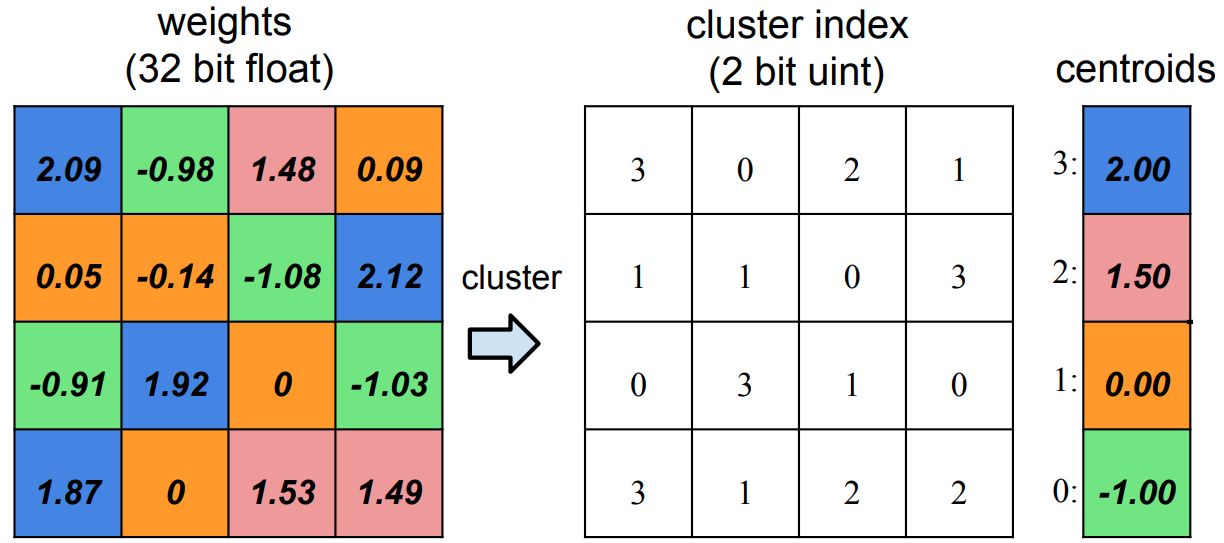

A $n$-bit k-means quantization will divide synapses into $2^n$ clusters, and synapses in the same cluster will share the same weight value.

Therefore, k-means quantization will create a codebook, inlcuding
*   `centroids`: $2^n$ fp32 cluster centers.
*   `labels`: a $n$-bit integer tensor with the same #elements of the original fp32 weights tensor. Each integer indicates which cluster it belongs to.

During the inference, a fp32 tensor is generated based on the codebook for inference:

> ***quantized_weight* = *codebook.centroids*\[*codebook.labels*\].view_as(weight)**

In [ ]:
from collections import namedtuple

Codebook = namedtuple('Codebook', ['centroids', 'labels'])

## Exercise 1

Complete the following K-Means quantization function.

In [ ]:
from fast_pytorch_kmeans import KMeans

def k_means_quantize(fp32_tensor: torch.Tensor, bitwidth=4, codebook=None):
    """
    quantize tensor using k-means clustering
    :param fp32_tensor:
    :param bitwidth: [int] quantization bit width, default=4
    :param codebook: [Codebook] (the cluster centroids, the cluster label tensor)
    :return:
        [Codebook = (centroids, labels)]
            centroids: [torch.(cuda.)FloatTensor] the cluster centroids
            labels: [torch.(cuda.)LongTensor] cluster label tensor
    """
    if codebook is None:
        ############### YOUR CODE STARTS HERE ###############
        # get number of clusters based on the quantization precision
        # hint: one line of code
        n_clusters = 0
        ############### YOUR CODE ENDS HERE #################
        # use k-means to get the quantization centroids
        kmeans = KMeans(n_clusters=n_clusters, mode='euclidean', verbose=0)
        labels = kmeans.fit_predict(fp32_tensor.view(-1, 1)).to(torch.long)
        centroids = kmeans.centroids.to(torch.float).view(-1)
        codebook = Codebook(centroids, labels)
    ############### YOUR CODE STARTS HERE ###############
    # decode the codebook into k-means quantized tensor for inference
    # hint: one line of code
    quantized_tensor = 0
    ############### YOUR CODE ENDS HERE #################
    fp32_tensor.set_(quantized_tensor.view_as(fp32_tensor))
    return codebook

<details>
<summary><b>Exercise 1: K-Means Quantization</b></summary>

```python
from fast_pytorch_kmeans import KMeans

def k_means_quantize(fp32_tensor: torch.Tensor, bitwidth=4, codebook=None):
    """
    quantize tensor using k-means clustering
    :param fp32_tensor:
    :param bitwidth: [int] quantization bit width, default=4
    :param codebook: [Codebook] (the cluster centroids, the cluster label tensor)
    :return:
        [Codebook = (centroids, labels)]
            centroids: [torch.(cuda.)FloatTensor] the cluster centroids
            labels: [torch.(cuda.)LongTensor] cluster label tensor
    """
    if codebook is None:
        # get number of clusters based on the quantization precision
        n_clusters = 1 << bitwidth  # 2^bitwidth
        # use k-means to get the quantization centroids
        kmeans = KMeans(n_clusters=n_clusters, mode='euclidean', verbose=0)
        labels = kmeans.fit_predict(fp32_tensor.view(-1, 1)).to(torch.long)
        centroids = kmeans.centroids.to(torch.float).view(-1)
        codebook = Codebook(centroids, labels)
    # decode the codebook into k-means quantized tensor for inference
    quantized_tensor = codebook.centroids[codebook.labels]
    fp32_tensor.set_(quantized_tensor.view_as(fp32_tensor))
    return codebook
```

</details>

Let's verify the functionality of defined k-means quantization by applying the function above on a dummy tensor.

In [ ]:
test_k_means_quantize()

## Exercise 2

The last code cell performs 2-bit k-means quantization and plots the tensor before and after the quantization. Each cluster is rendered with a unique color. There are 4 unique colors rendered in the quantized tensor.

The relationship between bit width and number of clusters is explained below.

In general, an $n$-bit k-means quantization produces $2^n$ clusters. So 2-bit quantization gives $2^2 = 4$ clusters (and 4 unique colors in the visualization), while 4-bit quantization gives $2^4 = 16$ clusters. The number of clusters grows exponentially with the bit width.

### Quantization Error in K-Means

Notice that the quantized tensor has only $2^n$ unique values (in this case, $2^2 = 4$), while the original tensor had many more distinct values. This means **information is lost** — the difference between each original weight and its assigned centroid is the **quantization error**.

K-Means clustering minimizes this error in the **least-squares** sense: each weight is assigned to its nearest centroid, and each centroid is the mean of its assigned weights. This is optimal for minimizing the total squared quantization error.

**Key question**: How does the number of bits affect the neural network's accuracy? The fewer the bits, the fewer the clusters, and the larger the average quantization error. We'll see the empirical impact below.

## K-Means Quantization on Whole Model

We now wrap the k-means quantization function into a class for quantizing the whole model. In class `KMeansQuantizer`, we have to keep a record of the codebooks (i.e., `centroids` and `labels`) so that we could apply or update the codebooks whenever the model weights change.

In [ ]:
from torch.nn import parameter
class KMeansQuantizer:
    def __init__(self, model : nn.Module, bitwidth=4):
        self.codebook = KMeansQuantizer.quantize(model, bitwidth)

    @torch.no_grad()
    def apply(self, model, update_centroids):
        for name, param in model.named_parameters():
            if name in self.codebook:
                if update_centroids:
                    update_codebook(param, codebook=self.codebook[name])
                self.codebook[name] = k_means_quantize(
                    param, codebook=self.codebook[name])

    @staticmethod
    @torch.no_grad()
    def quantize(model: nn.Module, bitwidth=4):
        codebook = dict()
        if isinstance(bitwidth, dict):
            for name, param in model.named_parameters():
                if name in bitwidth:
                    codebook[name] = k_means_quantize(param, bitwidth=bitwidth[name])
        else:
            for name, param in model.named_parameters():
                if param.dim() > 1:
                    codebook[name] = k_means_quantize(param, bitwidth=bitwidth)
        return codebook

Now let's quantize model into 8 bits, 4 bits and 2 bits using K-Means Quantization. *Note that we ignore the storage for codebooks when calculating the model size.*

In [ ]:
print('Note that the storage for codebooks is ignored when calculating the model size.')
quantizers = dict()
for bitwidth in [8, 4, 2]:
    recover_model()
    print(f'k-means quantizing model into {bitwidth} bits')
    quantizer = KMeansQuantizer(model, bitwidth)
    quantized_model_size = get_model_size(model, bitwidth)
    print(f"    {bitwidth}-bit k-means quantized model has size={quantized_model_size/MiB:.2f} MiB")
    quantized_model_accuracy = evaluate(model, dataloader['test'])
    print(f"    {bitwidth}-bit k-means quantized model has accuracy={quantized_model_accuracy:.2f}%")
    quantizers[bitwidth] = quantizer

### Key Limitation of K-Means Quantization

It is critical to understand what K-Means quantization does and does **not** provide:

> **K-Means quantization compresses STORAGE only — it does NOT speed up computation.**

Here's why: during inference, each weight index is used to **look up** its FP32 centroid from the codebook. After lookup, the actual computation (convolutions, matrix multiplications) proceeds in **full FP32 arithmetic**. The computational graph remains entirely floating-point.

```
Inference pipeline with K-Means quantization:
    quantized weights (n-bit indices)
           │
           ▼
    codebook lookup → FP32 weights
           │
           ▼
    FP32 convolution / matmul  ← still floating-point!
           │
           ▼
    FP32 output
```

This is a fundamental difference from **linear quantization** (covered next), which reformulates the computation itself in integer arithmetic.

### How Many Bits Per Layer?

Not all layers are equally sensitive to quantization. Experiments show that:

- **First and last layers** are typically more sensitive to quantization error
- Layers with **fewer parameters** need more bits (less redundancy to exploit)
- The optimal per-layer bitwidth can be found via **sensitivity analysis**: quantize one layer at a time and measure accuracy impact

In practice, networks like AlexNet can use 2 bits for convolutional layers and 4 bits for fully-connected layers with minimal accuracy loss.

## Trained K-Means Quantization

As we can see from the results of last cell, the accuracy significantly drops when quantizing the model into lower bits. Therefore, we have to perform quantization-aware training to recover the accuracy.

During the k-means quantization-aware training, the centroids are also updated, which is proposed in [Deep Compression: Compressing Deep Neural Networks With Pruning, Trained Quantization
And Huffman Coding](https://arxiv.org/pdf/1510.00149.pdf).

The gradient for the centroids is calculated as,

> $\frac{\partial \mathcal{L} }{\partial C_k} = \sum_{j} \frac{\partial \mathcal{L} }{\partial W_{j}} \frac{\partial W_{j} }{\partial C_k} = \sum_{j} \frac{\partial \mathcal{L} }{\partial W_{j}} \mathbf{1}(I_{j}=k)$

where $\mathcal{L}$ is the loss, $C_k$ is *k*-th centroid, $I_{j}$ is the label for weight $W_{j}$. $\mathbf{1}()$ is the indicator function, and $\mathbf{1}(I_{j}=k)$ means $1\;\mathrm{if}\;I_{j}=k\;\mathrm{else}\;0$, *i.e.*, $I_{j}==k$.

Here in the lab, **for simplicity**, we directly update the centroids according to the latest weights:

> $C_k = \frac{\sum_{j}W_{j}\mathbf{1}(I_{j}=k)}{\sum_{j}\mathbf{1}(I_{j}=k)}$

### Understanding the Gradient Grouping for Centroid Updates

The key idea of trained (quantization-aware) K-Means is that gradients computed for individual weights are **grouped by cluster** and **averaged** to produce a single update for each centroid.

Intuitively:
1. All weights in the same cluster share the same value (their centroid $C_k$)
2. During backpropagation, each weight $W_j$ gets its own gradient $\partial \mathcal{L} / \partial W_j$
3. To update centroid $C_k$, we aggregate the gradients of **all weights assigned to cluster $k$**:

> $\frac{\partial \mathcal{L}}{\partial C_k} = \sum_{j} \frac{\partial \mathcal{L}}{\partial W_j} \cdot \mathbf{1}(I_j = k)$

where $\mathbf{1}(I_j = k)$ is 1 if weight $W_j$ belongs to cluster $k$, and 0 otherwise.

The **simplified version** we implement in this lab directly recomputes centroids as the mean of current weight values in each cluster (after the weights have been updated by standard gradient descent), rather than performing gradient-based updates on the centroids themselves. This is equivalent when using a specific learning rate schedule and is simpler to implement.

### Exercise 3

Complete the following codebook update function.

**Hint**:

The above equation for updating centroids is indeed using the `mean` of weights in the same cluster to be the updated centroid value.

In [ ]:
def update_codebook(fp32_tensor: torch.Tensor, codebook: Codebook):
    """
    update the centroids in the codebook using updated fp32_tensor
    :param fp32_tensor: [torch.(cuda.)Tensor]
    :param codebook: [Codebook] (the cluster centroids, the cluster label tensor)
    """
    n_clusters = codebook.centroids.numel()
    fp32_tensor = fp32_tensor.view(-1)
    for k in range(n_clusters):
    ############### YOUR CODE STARTS HERE ###############
        # hint: one line of code
        codebook.centroids[k] = 0
    ############### YOUR CODE ENDS HERE #################

<details>
<summary><b>Exercise 3: Update Codebook</b></summary>

```python
def update_codebook(fp32_tensor: torch.Tensor, codebook: Codebook):
    """
    update the centroids in the codebook using updated fp32_tensor
    :param fp32_tensor: [torch.(cuda.)Tensor]
    :param codebook: [Codebook] (the cluster centroids, the cluster label tensor)
    """
    n_clusters = codebook.centroids.numel()
    fp32_tensor = fp32_tensor.view(-1)
    for k in range(n_clusters):
        codebook.centroids[k] = fp32_tensor[codebook.labels == k].mean()
```

</details>

Now let's run the following code cell to finetune the k-means quantized model to recover the accuracy. We will stop finetuning if accuracy drop is less than 0.5.

In [ ]:
accuracy_drop_threshold = 0.5
quantizers_before_finetune = copy.deepcopy(quantizers)
quantizers_after_finetune = quantizers

for bitwidth in [8, 4, 2]:
    recover_model()
    quantizer = quantizers[bitwidth]
    print(f'k-means quantizing model into {bitwidth} bits')
    quantizer.apply(model, update_centroids=False)
    quantized_model_size = get_model_size(model, bitwidth)
    print(f"    {bitwidth}-bit k-means quantized model has size={quantized_model_size/MiB:.2f} MiB")
    quantized_model_accuracy = evaluate(model, dataloader['test'])
    print(f"    {bitwidth}-bit k-means quantized model has accuracy={quantized_model_accuracy:.2f}% before quantization-aware training ")
    accuracy_drop = fp32_model_accuracy - quantized_model_accuracy
    if accuracy_drop > accuracy_drop_threshold:
        print(f"        Quantization-aware training due to accuracy drop={accuracy_drop:.2f}% is larger than threshold={accuracy_drop_threshold:.2f}%")
        num_finetune_epochs = 5
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_finetune_epochs)
        criterion = nn.CrossEntropyLoss()
        best_accuracy = 0
        epoch = num_finetune_epochs
        while accuracy_drop > accuracy_drop_threshold and epoch > 0:
            train(model, dataloader['train'], criterion, optimizer, scheduler,
                  callbacks=[lambda: quantizer.apply(model, update_centroids=True)])
            model_accuracy = evaluate(model, dataloader['test'])
            is_best = model_accuracy > best_accuracy
            best_accuracy = max(model_accuracy, best_accuracy)
            print(f'        Epoch {num_finetune_epochs-epoch} Accuracy {model_accuracy:.2f}% / Best Accuracy: {best_accuracy:.2f}%')
            accuracy_drop = fp32_model_accuracy - best_accuracy
            epoch -= 1
    else:
        print(f"        No need for quantization-aware training since accuracy drop={accuracy_drop:.2f}% is smaller than threshold={accuracy_drop_threshold:.2f}%")

# Linear Quantization

## Why Linear Quantization Matters

Unlike K-Means quantization, which only saves storage, linear quantization enables **integer-only computation** during inference. This is the dominant quantization approach used in production deployments:

- **TensorFlow Lite**: default quantization for mobile/edge
- **PyTorch Mobile / ExecuTorch**: INT8 quantization
- **NVIDIA TensorRT**: INT8/INT4 inference on GPUs
- **Apple CoreML**: INT8 quantization for iOS/macOS

The fundamental insight: if we constrain the mapping between real values and integers to be **affine** (a linear function plus an offset), then matrix multiplications and convolutions can be reformulated **entirely in the integer domain**. This means we get both storage reduction AND computational speedup.

In this section, we will implement and perform linear quantization.

Linear quantization directly rounds the floating-point value into the nearest quantized integer after range truncation and scaling.

[Linear quantization](https://arxiv.org/pdf/1712.05877.pdf) can be represented as

$r = S(q-Z)$

where $r$ is a floating point real number, $q$ is a *n*-bit integer, $Z$ is a *n*-bit integer, and $S$ is a floating point real number. $Z$ is quantization zero point and $S$ is quantization scaling factor. Both constant $Z$ and $S$ are quantization parameters.

## Understanding the Affine Mapping: $r = S(q - Z)$

Let's carefully break down this equation. Every quantity has a specific type:

| Symbol | Name | Type | Description |
|---|---|---|---|
| $r$ | Real value | **FP32** | The original floating-point weight or activation |
| $q$ | Quantized value | **$n$-bit integer** | The integer representation stored in memory |
| $S$ | Scale | **FP32** | Step size between consecutive quantized levels |
| $Z$ | Zero point | **$n$-bit integer** | The integer that maps exactly to real value $r = 0$ |

It is **critical** to keep track of which quantities are floating-point and which are integer — this determines what operations can be performed in integer arithmetic during inference.

### Visual Intuition

Think of the quantization as a ruler:
- The **markings** on the ruler are at integer positions: $q_{\min}, \ldots, -1, 0, 1, \ldots, q_{\max}$
- The **scale** $S$ determines the physical distance between consecutive markings
- The **zero point** $Z$ determines which marking aligns with real value $0$

The quantized range $[q_{\min}, q_{\max}]$ depends on the bit-width:

| Bit Width | $q_{\min}$ | $q_{\max}$ | Total Levels |
|---|---|---|---|
| 2 | $-2$ | $1$ | 4 |
| 3 | $-4$ | $3$ | 8 |
| 4 | $-8$ | $7$ | 16 |
| 8 | $-128$ | $127$ | 256 |
| $n$ | $-2^{n-1}$ | $2^{n-1}-1$ | $2^n$ |

### Worked Example: 2-bit Quantization (from the lecture slides)

Consider this weight matrix:

$$\mathbf{W} = \begin{bmatrix} 2.09 & -0.98 & 1.48 & 0.09 \\ 0.05 & -0.14 & -1.08 & 2.12 \\ -0.91 & 1.92 & 0 & -1.03 \\ 1.87 & 0 & 1.53 & 1.49 \end{bmatrix}$$

With 2-bit signed quantization: $q \in \{-2, -1, 0, 1\}$

$r_{\max} = 2.12, \quad r_{\min} = -1.08$

**Step 1 — Compute Scale:**

> $S = \frac{r_{\max} - r_{\min}}{q_{\max} - q_{\min}} = \frac{2.12 - (-1.08)}{1 - (-2)} = \frac{3.20}{3} = 1.067$

**Step 2 — Compute Zero Point:**

> $Z = \text{round}\left(q_{\min} - \frac{r_{\min}}{S}\right) = \text{round}\left(-2 - \frac{-1.08}{1.067}\right) = \text{round}(-2 + 1.012) = \text{round}(-0.988) = -1$

**Step 3 — Quantize** each weight: $q = \text{clamp}(\text{round}(r / S) + Z, \; q_{\min}, \; q_{\max})$

**Step 4 — Reconstruct**: $\hat{r} = S \cdot (q - Z) = 1.067 \cdot (q + 1)$

**Verification of boundary mapping:**
- $r_{\min} \approx S(q_{\min} - Z) = 1.067 \times (-2 - (-1)) = 1.067 \times (-1) = -1.067 \approx -1.08$ ✓
- $r_{\max} \approx S(q_{\max} - Z) = 1.067 \times (1 - (-1)) = 1.067 \times 2 = 2.134 \approx 2.12$ ✓

The code cell below implements this exact example so you can see the quantization and reconstruction in action.

In [ ]:
# Worked example: 2-bit linear quantization (matching the lecture slides)
import torch

# Original weight matrix from the slides
W = torch.tensor([
    [ 2.09, -0.98,  1.48,  0.09],
    [ 0.05, -0.14, -1.08,  2.12],
    [-0.91,  1.92,  0.00, -1.03],
    [ 1.87,  0.00,  1.53,  1.49]
])

bitwidth = 2
q_min = -(1 << (bitwidth - 1))       # -2
q_max = (1 << (bitwidth - 1)) - 1    # 1

r_min = W.min().item()
r_max = W.max().item()

# Step 1: Compute scale
S = (r_max - r_min) / (q_max - q_min)

# Step 2: Compute zero point
Z = round(q_min - r_min / S)

print(f"Original weights range: [{r_min:.2f}, {r_max:.2f}]")
print(f"Quantized range: [{q_min}, {q_max}]")
print(f"Scale S = {S:.4f}")
print(f"Zero point Z = {Z}")

# Step 3: Quantize
q_W = (W / S + Z).round().clamp(q_min, q_max).to(torch.int8)
print(f"\nQuantized matrix (2-bit integers):")
print(q_W)

# Step 4: Reconstruct
W_reconstructed = S * (q_W.float() - Z)
print(f"\nReconstructed weights:")
for row in W_reconstructed:
    print("  " + "  ".join(f"{v:6.2f}" for v in row.tolist()))

# Quantization error
error = W - W_reconstructed
print(f"\nQuantization error:")
for row in error:
    print("  " + "  ".join(f"{v:+6.3f}" for v in row.tolist()))

print(f"\nMax |error| = {error.abs().max():.4f}")
print(f"Mean |error| = {error.abs().mean():.4f}")
print(f"\nOnly {len(q_W.unique())} unique quantized values for {W.numel()} weights → {32/bitwidth:.0f}x compression")

## *n*-bit Integer

A *n*-bit signed integer is usually represented in [two's complement](https://en.wikipedia.org/wiki/Two%27s_complement) notation.

A *n*-bit signed integer can enode integers in the range $[-2^{n-1}, 2^{n-1}-1]$. For example, a 8-bit integer falls in the range [-128, 127].

In [ ]:
def get_quantized_range(bitwidth):
    quantized_max = (1 << (bitwidth - 1)) - 1
    quantized_min = -(1 << (bitwidth - 1))
    return quantized_min, quantized_max

## **Exercise 4**

Complete the following linear quantization function.

**Hint**:
*   From $r=S(q-Z)$, we have $q = r/S + Z$.
*   Both $r$ and $S$ are floating numbers, and thus we cannot directly add integer $Z$ to $r/S$. Therefore $q = \mathrm{int}(\mathrm{round}(r/S)) + Z$.
*   To convert [`torch.FloatTensor`](https://pytorch.org/docs/stable/tensors.html) to [`torch.IntTensor`](https://pytorch.org/docs/stable/tensors.html), we could use [`torch.round()`](https://pytorch.org/docs/stable/generated/torch.round.html#torch.round), [`torch.Tensor.round()`](https://pytorch.org/docs/stable/generated/torch.Tensor.round.html#torch.Tensor.round), [`torch.Tensor.round_()`](https://pytorch.org/docs/stable/generated/torch.Tensor.round_) to first convert all values to floating integer, and then use [`torch.Tensor.to(torch.int8)`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html#torch.Tensor.to) to convert the data type from [`torch.float`](https://pytorch.org/docs/stable/tensors.html) to [`torch.int8`](https://pytorch.org/docs/stable/tensors.html).



In [ ]:
def linear_quantize(fp_tensor, bitwidth, scale, zero_point, dtype=torch.int8) -> torch.Tensor:
    """
    linear quantization for single fp_tensor
      from
        fp_tensor = (quantized_tensor - zero_point) * scale
      we have,
        quantized_tensor = int(round(fp_tensor / scale)) + zero_point
    :param tensor: [torch.(cuda.)FloatTensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :param scale: [torch.(cuda.)FloatTensor] scaling factor
    :param zero_point: [torch.(cuda.)IntTensor] the desired centroid of tensor values
    :return:
        [torch.(cuda.)FloatTensor] quantized tensor whose values are integers
    """
    assert(fp_tensor.dtype == torch.float)
    assert(isinstance(scale, float) or
           (scale.dtype == torch.float and scale.dim() == fp_tensor.dim()))
    assert(isinstance(zero_point, int) or
           (zero_point.dtype == dtype and zero_point.dim() == fp_tensor.dim()))

    ############### YOUR CODE STARTS HERE ###############
    # Step 1: scale the fp_tensor
    scaled_tensor = 0
    # Step 2: round the floating value to integer value
    rounded_tensor = 0
    ############### YOUR CODE ENDS HERE #################

    rounded_tensor = rounded_tensor.to(dtype)

    ############### YOUR CODE STARTS HERE ###############
    # Step 3: shift the rounded_tensor to make zero_point 0
    shifted_tensor = 0
    ############### YOUR CODE ENDS HERE #################

    # Step 4: clamp the shifted_tensor to lie in bitwidth-bit range
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    quantized_tensor = shifted_tensor.clamp_(quantized_min, quantized_max)
    return quantized_tensor

<details>
<summary><b>Exercise 4: Linear Quantization</b></summary>

```python
def linear_quantize(fp_tensor, bitwidth, scale, zero_point, dtype=torch.int8) -> torch.Tensor:
    """
    linear quantization for single fp_tensor
      from
        fp_tensor = (quantized_tensor - zero_point) * scale
      we have,
        quantized_tensor = int(round(fp_tensor / scale)) + zero_point
    :param tensor: [torch.(cuda.)FloatTensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :param scale: [torch.(cuda.)FloatTensor] scaling factor
    :param zero_point: [torch.(cuda.)IntTensor] the desired centroid of tensor values
    :return:
        [torch.(cuda.)FloatTensor] quantized tensor whose values are integers
    """
    assert(fp_tensor.dtype == torch.float)
    assert(isinstance(scale, float) or
           (scale.dtype == torch.float and scale.dim() == fp_tensor.dim()))
    assert(isinstance(zero_point, int) or
           (zero_point.dtype == dtype and zero_point.dim() == fp_tensor.dim()))

    # Step 1: scale the fp_tensor
    scaled_tensor = fp_tensor / scale
    # Step 2: round the floating value to integer value
    rounded_tensor = scaled_tensor.round()

    rounded_tensor = rounded_tensor.to(dtype)

    # Step 3: shift the rounded_tensor to make zero_point 0
    shifted_tensor = rounded_tensor + zero_point

    # Step 4: clamp the shifted_tensor to lie in bitwidth-bit range
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    quantized_tensor = shifted_tensor.clamp_(quantized_min, quantized_max)
    return quantized_tensor
```

</details>

Let's verify the functionality of defined linear quantization by applying the function above on a dummy tensor.

In [ ]:
test_linear_quantize()

## Exercise 5

Now we have to determine the scaling factor $S$ and zero point $Z$ for linear quantization.

Recall that [linear quantization](https://arxiv.org/pdf/1712.05877.pdf) can be represented as

$r = S(q-Z)$

### Scale

Linear quantization projects the floating point range [*fp_min*, *fp_max*] to the quantized range [*quantized_min*, *quantized_max*]. That is to say,

> $r_{\mathrm{max}} = S(q_{\mathrm{max}}-Z)$
>
> $r_{\mathrm{min}} = S(q_{\mathrm{min}}-Z)$

Substracting these two equations, we have,


By subtracting the two boundary equations, the $Z$ terms cancel out and we get:

> $S = (r_{\mathrm{max}} - r_{\mathrm{min}}) / (q_{\mathrm{max}} - q_{\mathrm{min}})$

This makes intuitive sense: the scale factor maps the full floating-point range to the full quantized integer range.


There are different approaches to determine the $r_{\mathrm{min}}$ and  $r_{\mathrm{max}}$ of a floating point tensor `fp_tensor`.

*   The most common method is directly using the minimum and maximum value of `fp_tensor`.
*   Another widely used method is minimizing Kullback-Leibler-J divergence to determine the *fp_max*.

### zero point

Once we determine the scaling factor $S$, we can directly use the relationship between $r_{\mathrm{min}}$ and $q_{\mathrm{min}}$ to calculate the zero point $Z$.

From $r_{\mathrm{min}} = S(q_{\mathrm{min}} - Z)$ we can solve for $Z$:

> $Z = q_{\mathrm{min}} - r_{\mathrm{min}} / S$

Since $Z$ must be an integer, we round:

> $Z = \mathrm{int}(\mathrm{round}(q_{\mathrm{min}} - r_{\mathrm{min}} / S))$

### Numerical Example for Scale and Zero Point

Let's verify the formulas with concrete numbers from our worked example:

**Given**: $r_{\min} = -1.08$, $r_{\max} = 2.12$, $q_{\min} = -2$, $q_{\max} = 1$ (2-bit signed)

**Scale**:

> $S = \frac{r_{\max} - r_{\min}}{q_{\max} - q_{\min}} = \frac{2.12 - (-1.08)}{1 - (-2)} = \frac{3.20}{3} \approx 1.067$

**Zero Point**:

> $Z = \text{round}\left(q_{\min} - \frac{r_{\min}}{S}\right) = \text{round}\left(-2 - \frac{-1.08}{1.067}\right) = \text{round}(-2 + 1.012) = \text{round}(-0.988) = -1$

**Verification** — both boundary equations should be approximately satisfied:

> $r_{\min} \approx S(q_{\min} - Z) = 1.067 \times (-2 - (-1)) = 1.067 \times (-1) = -1.067 \approx -1.08$ ✓
>
> $r_{\max} \approx S(q_{\max} - Z) = 1.067 \times (1 - (-1)) = 1.067 \times 2 = 2.134 \approx 2.12$ ✓

Small discrepancies arise because $Z$ must be rounded to an integer, but the error is at most $S/2$ at the boundaries.

### Exercise 5.1

Complete the following function for calculating the scale $S$ and zero point $Z$ from floating point tensor $r$.


In [ ]:
def get_quantization_scale_and_zero_point(fp_tensor, bitwidth):
    """
    get quantization scale for single tensor
    :param fp_tensor: [torch.(cuda.)Tensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [float] scale
        [int] zero_point
    """
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    fp_max = fp_tensor.max().item()
    fp_min = fp_tensor.min().item()

    ############### YOUR CODE STARTS HERE ###############
    # hint: one line of code for calculating scale
    scale = 0
    # hint: one line of code for calculating zero_point
    zero_point = 0
    ############### YOUR CODE ENDS HERE #################

    # clip the zero_point to fall in [quantized_min, quantized_max]
    if zero_point < quantized_min:
        zero_point = quantized_min
    elif zero_point > quantized_max:
        zero_point = quantized_max
    else: # convert from float to int using round()
        zero_point = round(zero_point)
    return scale, int(zero_point)

<details>
<summary><b>Exercise 5.1: Scale and Zero Point</b></summary>

```python
def get_quantization_scale_and_zero_point(fp_tensor, bitwidth):
    """
    get quantization scale for single tensor
    :param fp_tensor: [torch.(cuda.)Tensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [float] scale
        [int] zero_point
    """
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    fp_max = fp_tensor.max().item()
    fp_min = fp_tensor.min().item()

    scale = (fp_max - fp_min) / (quantized_max - quantized_min)
    zero_point = quantized_min - fp_min / scale

    # clip the zero_point to fall in [quantized_min, quantized_max]
    if zero_point < quantized_min:
        zero_point = quantized_min
    elif zero_point > quantized_max:
        zero_point = quantized_max
    else: # convert from float to int using round()
        zero_point = round(zero_point)
    return scale, int(zero_point)
```

</details>

We now wrap  `linear_quantize()` and `get_quantization_scale_and_zero_point()` defined above into one function.

In [ ]:
def linear_quantize_feature(fp_tensor, bitwidth):
    """
    linear quantization for feature tensor
    :param fp_tensor: [torch.(cuda.)Tensor] floating feature to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [torch.(cuda.)Tensor] quantized tensor
        [float] scale tensor
        [int] zero point
    """
    scale, zero_point = get_quantization_scale_and_zero_point(fp_tensor, bitwidth)
    quantized_tensor = linear_quantize(fp_tensor, bitwidth, scale, zero_point)
    return quantized_tensor, scale, zero_point

## Special case: linear quantization on weight tensor

Let's first see the distribution of weight values.

In [ ]:
def plot_weight_distribution(model, bitwidth=32):
    # bins = (1 << bitwidth) if bitwidth <= 8 else 256
    if bitwidth <= 8:
        qmin, qmax = get_quantized_range(bitwidth)
        bins = np.arange(qmin, qmax + 2)
        align = 'left'
    else:
        bins = 256
        align = 'mid'
    fig, axes = plt.subplots(3,3, figsize=(10, 6))
    axes = axes.ravel()
    plot_index = 0
    for name, param in model.named_parameters():
        if param.dim() > 1:
            ax = axes[plot_index]
            ax.hist(param.detach().view(-1).cpu(), bins=bins, density=True,
                    align=align, color = 'blue', alpha = 0.5,
                    edgecolor='black' if bitwidth <= 4 else None)
            if bitwidth <= 4:
                quantized_min, quantized_max = get_quantized_range(bitwidth)
                ax.set_xticks(np.arange(start=quantized_min, stop=quantized_max+1))
            ax.set_xlabel(name)
            ax.set_ylabel('density')
            plot_index += 1
    fig.suptitle(f'Histogram of Weights (bitwidth={bitwidth} bits)')
    fig.tight_layout()
    fig.subplots_adjust(top=0.925)
    plt.show()

recover_model()
plot_weight_distribution(model)

As we can see from the histograms above, the distribution of weight values are nearly symmetric about 0 (except for the classifier in this case). Therefore, we usually make zero point $Z=0$ when quantizating the weights.

From $r = S(q-Z)$, we have

> $r_{\mathrm{max}} = S \cdot q_{\mathrm{max}}$

and then

> $S = r_{\mathrm{max}} / q_{\mathrm{max}}$

We directly use the maximum magnitude of weight values as $r_{\mathrm{max}}$.

In [ ]:
def get_quantization_scale_for_weight(weight, bitwidth):
    """
    get quantization scale for single tensor of weight
    :param weight: [torch.(cuda.)Tensor] floating weight to be quantized
    :param bitwidth: [integer] quantization bit width
    :return:
        [floating scalar] scale
    """
    # we just assume values in weight are symmetric
    # we also always make zero_point 0 for weight
    fp_max = max(weight.abs().max().item(), 5e-7)
    _, quantized_max = get_quantized_range(bitwidth)
    return fp_max / quantized_max

### Per-channel Linear Quantization

Recall that for 2D convolution, the weight tensor is a 4-D tensor in the shape of (num_output_channels, num_input_channels, kernel_height, kernel_width).

Intensive experiments show that using the different scaling factors $S$ and zero points $Z$ for different output channels will perform better. Therefore, we have to determine scaling factor $S$ and zero point $Z$ for the subtensor of each output channel independently.

In [ ]:
def linear_quantize_weight_per_channel(tensor, bitwidth):
    """
    linear quantization for weight tensor
        using different scales and zero_points for different output channels
    :param tensor: [torch.(cuda.)Tensor] floating weight to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [torch.(cuda.)Tensor] quantized tensor
        [torch.(cuda.)Tensor] scale tensor
        [int] zero point (which is always 0)
    """
    dim_output_channels = 0
    num_output_channels = tensor.shape[dim_output_channels]
    scale = torch.zeros(num_output_channels, device=tensor.device)
    for oc in range(num_output_channels):
        _subtensor = tensor.select(dim_output_channels, oc)
        _scale = get_quantization_scale_for_weight(_subtensor, bitwidth)
        scale[oc] = _scale
    scale_shape = [1] * tensor.dim()
    scale_shape[dim_output_channels] = -1
    scale = scale.view(scale_shape)
    quantized_tensor = linear_quantize(tensor, bitwidth, scale, zero_point=0)
    return quantized_tensor, scale, 0

### A Quick Peek at Linear Quantization on Weights

Now let's have a peek on the weight distribution and model size when applying linear quantization on weights with different bitwidths.

In [ ]:
@torch.no_grad()
def peek_linear_quantization():
    for bitwidth in [4, 2]:
        for name, param in model.named_parameters():
            if param.dim() > 1:
                quantized_param, scale, zero_point = \
                    linear_quantize_weight_per_channel(param, bitwidth)
                param.copy_(quantized_param)
        plot_weight_distribution(model, bitwidth)
        recover_model()

peek_linear_quantization()

## From Quantized Weights to Quantized Inference

So far, we have learned how to **quantize the weights** of a model — converting FP32 weight tensors into low-bit integers plus scale and zero point parameters. But merely storing weights as integers is not enough. If we simply dequantize (convert back to FP32) before every computation, we're back to floating-point inference — just like K-Means!

The real power of linear quantization comes from reformulating the entire **inference computation** in the integer domain. In the next section, we will derive how:

1. Matrix multiplications become **integer multiply-accumulate** operations
2. Bias additions stay in the **integer domain** with proper constraints
3. Only a **single rescaling** step per layer requires floating-point (and even this can be approximated with fixed-point arithmetic)

This is what makes linear quantization practical for deployment: **both storage AND computation** benefit from reduced precision.

### An Analogy Before We Begin: Currency Conversion

Imagine you run a business that operates in three currencies: Euros, Dollars, and Yen.

**Approach A (naive):** Every time you need to multiply prices together, you convert everything into Euros (floating-point), do the math, then convert the result into the target currency. This works, but the conversion step is expensive and you do it constantly.

**Approach B (smart):** You figure out a way to do arithmetic directly in the integer "cents" of each currency. You only convert once, at the very end, to get the final price in the target currency.

**Quantized inference is Approach B.** We will work directly with the integer values $q$ (the "cents"), perform all the heavy computation (convolutions, matrix multiplies) using fast integer arithmetic, and only convert to real values once at the output. The derivation below shows exactly how to make this work.

## Quantized Inference

### The Goal: Integer-Only Arithmetic Pipeline

Before diving into the math, let's understand what we're trying to achieve. The inference pipeline for a single quantized layer looks like this:

```
  Quantized Input (N-bit int)     Quantized Weights (N-bit int)
         │                                  │
         └──────────┬───────────────────────┘
                    ▼
         N-bit Integer Multiply-Accumulate
                    │
                    ▼
         32-bit Integer Accumulator  ←── + Precomputed Q_bias (32-bit int)
                    │
                    ▼
         Rescale by (S_in × S_w / S_out)  ←── the ONE float operation
                    │
                    ▼
         + Z_output (N-bit int add)
                    │
                    ▼
         Quantized Output (N-bit int)
```

The key insight: **the only floating-point operation is the rescaling step**, and even that can be converted to fixed-point integer arithmetic using a clever trick (explained below).

Let us now derive the formulas that make this pipeline possible.

### Derivation Roadmap

Take a breath. We are about to derive the key formula of this entire section. It may look long, but **every single step is one simple algebraic manipulation** -- there are no tricks, no leaps of logic. We will walk through it together.

Here is where we are headed. By the end of these 12 steps, we will have derived:

> **Final Formula:** $\;\;q_{\mathrm{output}} = \Big(\mathrm{CONV}[q_{\mathrm{input}}, q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big) \cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}} + Z_{\mathrm{output}}$

...where almost everything is an **integer operation**.

**The 12 steps at a glance:**

| Step | What we do |
|------|------------|
| 1 | Write down the quantization equations for each tensor |
| 2 | Simplify the weight equation (because $Z_{\mathrm{weight}} = 0$) |
| 3 | Write the standard floating-point convolution formula |
| 4 | Substitute the quantization equations into the convolution |
| 5 | Factor out the scale constants from CONV |
| 6 | Choose clever values for $Z_{\mathrm{bias}}$ and $S_{\mathrm{bias}}$ |
| 7 | Expand CONV using linearity (distributive property) |
| 8 | Define a precomputed bias term $Q_{\mathrm{bias}}$ |
| 9 | Use the output quantization equation |
| 10 | Solve for $q_{\mathrm{output}}$ -- **the final formula** |
| 11 | Write the analogous formula for fully-connected layers |
| 12 | Summarize: what is integer vs. float, precomputed vs. runtime |

If you get lost at any point, come back to this table to see where you are. Let's begin.

### Step 1 of 12: Write Down the Quantization Equations

**What we are doing:** Our starting point is the linear quantization equation $r = S(q - Z)$, applied separately to each tensor in the layer: input, weight, bias, and output.

> $r_{\mathrm{input}} = S_{\mathrm{input}}(q_{\mathrm{input}} - Z_{\mathrm{input}})$
>
> $r_{\mathrm{weight}} = S_{\mathrm{weight}}(q_{\mathrm{weight}} - Z_{\mathrm{weight}})$
>
> $r_{\mathrm{bias}} = S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}})$
>
> $r_{\mathrm{output}} = S_{\mathrm{output}}(q_{\mathrm{output}} - Z_{\mathrm{output}})$

Here, $r$ denotes the **real (floating-point) value**, $q$ is the **quantized (integer) value**, $S$ is the **scale** (a positive float), and $Z$ is the **zero point** (an integer).

**What just happened:** Nothing surprising yet -- we just wrote the same formula four times, once for each tensor. These four equations are the building blocks for everything that follows.

### Step 2 of 12: Simplify the Weight Equation ($Z_{\mathrm{weight}} = 0$)

**What we are doing:** Recall from the earlier section on symmetric quantization that we quantize weights **symmetrically**, meaning the zero point for weights is always zero: $Z_{\mathrm{weight}} = 0$.

Plugging this into the weight equation from Step 1:

> $r_{\mathrm{weight}} = S_{\mathrm{weight}}(q_{\mathrm{weight}} - \underbrace{Z_{\mathrm{weight}}}_{= 0}) = S_{\mathrm{weight}} \cdot q_{\mathrm{weight}}$

**What just happened:** We dropped one term. The weight equation is now simpler: the real-valued weight is just the scale times the integer weight. This small simplification will make every subsequent step cleaner.

### Step 3 of 12: Write the Standard Floating-Point Convolution

**What we are doing:** Before we touch any quantization, let's write down the formula for a normal (FP32) convolution with bias. This is the computation we want to replicate in the integer domain.

> $r_{\mathrm{output}} = \mathrm{CONV}[r_{\mathrm{input}},\; r_{\mathrm{weight}}] + r_{\mathrm{bias}}$

For a fully-connected layer, replace CONV with Linear (matrix multiply), but the structure is the same.

**What just happened:** We wrote the "target" -- the real-valued computation we want to express entirely in terms of the quantized variables $q$. Our goal for the next several steps is to rewrite the right-hand side so it uses $q_{\mathrm{input}}$, $q_{\mathrm{weight}}$, and $q_{\mathrm{bias}}$ instead of $r_{\mathrm{input}}$, $r_{\mathrm{weight}}$, and $r_{\mathrm{bias}}$.

### Step 4 of 12: Substitute the Quantization Equations

**What we are doing:** We now take the convolution from Step 3 and replace every $r$ with its quantization equation from Steps 1-2. This is purely mechanical substitution -- no algebra tricks.

Starting from:
> $r_{\mathrm{output}} = \mathrm{CONV}[r_{\mathrm{input}},\; r_{\mathrm{weight}}] + r_{\mathrm{bias}}$

Replace $r_{\mathrm{input}}$ with $S_{\mathrm{input}}(q_{\mathrm{input}} - Z_{\mathrm{input}})$, replace $r_{\mathrm{weight}}$ with $S_{\mathrm{weight}} \cdot q_{\mathrm{weight}}$ (from Step 2), and replace $r_{\mathrm{bias}}$ with $S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}})$:

> $r_{\mathrm{output}} = \mathrm{CONV}\Big[S_{\mathrm{input}}(q_{\mathrm{input}} - Z_{\mathrm{input}}),\;\; S_{\mathrm{weight}} \cdot q_{\mathrm{weight}}\Big] + S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}})$

**What just happened:** The equation looks messier now, but this is progress -- the right-hand side now contains only quantization parameters ($S$, $Z$) and integer values ($q$). No more $r$ terms on the right. Next, we will simplify.

### Step 5 of 12: Factor Out the Scales from CONV

**What we are doing:** The scales $S_{\mathrm{input}}$ and $S_{\mathrm{weight}}$ are just scalar constants (single numbers, not tensors). Convolution is **linear** in both its arguments, so we can pull these constants out of the CONV operation, just like you can pull a constant out of a sum: $\sum c \cdot x_i = c \cdot \sum x_i$.

> $r_{\mathrm{output}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot \mathrm{CONV}\Big[q_{\mathrm{input}} - Z_{\mathrm{input}},\;\; q_{\mathrm{weight}}\Big] + S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}})$

**KEY INSIGHT:** Look at what is inside the CONV brackets now: $q_{\mathrm{input}} - Z_{\mathrm{input}}$ and $q_{\mathrm{weight}}$ are **all integers**! The scales are outside. This means the actual convolution (the heavy computation) can be performed using **integer arithmetic only**.

**What just happened:** By factoring out the scales, we isolated the integer computation inside CONV. The scales just multiply the result afterward.

### Step 6 of 12: Choose Bias Constraints ($Z_{\mathrm{bias}} = 0$, $S_{\mathrm{bias}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}}$)

**What we are doing:** We have freedom to choose $S_{\mathrm{bias}}$ and $Z_{\mathrm{bias}}$ however we want (they are parameters under our control). We now make a **strategic choice** that will simplify the formula dramatically.

We set:
> $Z_{\mathrm{bias}} = 0 \quad$ and $\quad S_{\mathrm{bias}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}}$

With these choices, the bias term becomes:
> $S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}}) = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot q_{\mathrm{bias}}$

Now substitute this back into our equation from Step 5:
> $r_{\mathrm{output}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot \mathrm{CONV}[q_{\mathrm{input}} - Z_{\mathrm{input}},\; q_{\mathrm{weight}}] + S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot q_{\mathrm{bias}}$

Factor out $S_{\mathrm{input}} \cdot S_{\mathrm{weight}}$:
> $r_{\mathrm{output}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot \Big(\mathrm{CONV}[q_{\mathrm{input}} - Z_{\mathrm{input}},\; q_{\mathrm{weight}}] + q_{\mathrm{bias}}\Big)$

**Why this is clever:** The bias term $q_{\mathrm{bias}}$ now has the **same scale** as the convolution output, so we can add them as **plain integers** inside the parentheses. The entire expression inside the parentheses is integer arithmetic!

**What just happened:** By choosing $S_{\mathrm{bias}}$ to match the convolution's scale, we made the bias "compatible" with the convolution output in the integer domain. No extra conversion needed.

### Step 7 of 12: Expand CONV Using Linearity (Distributive Property)

**What we are doing:** Inside the CONV, we have $q_{\mathrm{input}} - Z_{\mathrm{input}}$ as the first argument. Since convolution is linear (it distributes over addition/subtraction), we can split this into two separate convolutions:

> $\mathrm{CONV}[q_{\mathrm{input}} - Z_{\mathrm{input}},\; q_{\mathrm{weight}}] = \mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] - \mathrm{CONV}[Z_{\mathrm{input}},\; q_{\mathrm{weight}}]$

So our full equation becomes:
> $r_{\mathrm{output}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot \Big(\mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] - \mathrm{CONV}[Z_{\mathrm{input}},\; q_{\mathrm{weight}}] + q_{\mathrm{bias}}\Big)$

**Why did we do this?** Look at the two CONV terms:
- $\mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}]$: depends on the **input data** -- must be computed at inference time
- $\mathrm{CONV}[Z_{\mathrm{input}},\; q_{\mathrm{weight}}]$: depends only on **constants** ($Z_{\mathrm{input}}$ is fixed, $q_{\mathrm{weight}}$ is fixed) -- can be **precomputed** before inference!

**What just happened:** We separated the "data-dependent" part from the "constant" part. This sets up the next step where we fold the constant part into the bias.

### Step 8 of 12: Define $Q_{\mathrm{bias}}$ (the Precomputed Bias)

**What we are doing:** Since $Z_{\mathrm{input}}$ and $q_{\mathrm{weight}}$ are both known before inference begins, we can precompute $\mathrm{CONV}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$ and fold it into the bias. We define:

> $Q_{\mathrm{bias}} \;=\; q_{\mathrm{bias}} \;-\; \mathrm{CONV}[Z_{\mathrm{input}},\; q_{\mathrm{weight}}]$

This is a **32-bit integer vector** (one value per output channel), computed **once** before inference and stored.

Substituting into our equation from Step 7:

> $r_{\mathrm{output}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot \Big(\underbrace{\mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}]}_{\text{integer MAC at inference}} + \underbrace{Q_{\mathrm{bias}}}_{\text{precomputed integer}}\Big)$

**What just happened:** We combined the original bias and the zero-point correction into a single precomputed term $Q_{\mathrm{bias}}$. At inference time, we just add this integer vector to the convolution result -- simple and fast.

### Step 9 of 12: Use the Output Quantization Equation

**What we are doing:** The left-hand side of our equation still says $r_{\mathrm{output}}$ (a real-valued output). But we want the **quantized** output $q_{\mathrm{output}}$. So we use the output quantization equation from Step 1:

> $r_{\mathrm{output}} = S_{\mathrm{output}}(q_{\mathrm{output}} - Z_{\mathrm{output}})$

Setting the two expressions for $r_{\mathrm{output}}$ equal:

> $S_{\mathrm{output}}(q_{\mathrm{output}} - Z_{\mathrm{output}}) = S_{\mathrm{input}} \cdot S_{\mathrm{weight}} \cdot \Big(\mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big)$

**What just happened:** Both sides of the equation now contain only quantization parameters ($S$, $Z$) and integer quantities ($q$, $Q_{\mathrm{bias}}$). We are one step away from isolating $q_{\mathrm{output}}$.

### Step 10 of 12: Solve for $q_{\mathrm{output}}$ -- THE FINAL FORMULA

**What we are doing:** Simple algebra -- divide both sides by $S_{\mathrm{output}}$, then add $Z_{\mathrm{output}}$ to both sides.

Divide by $S_{\mathrm{output}}$:

> $q_{\mathrm{output}} - Z_{\mathrm{output}} = \Big(\mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big) \cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}$

Add $Z_{\mathrm{output}}$ to both sides:

> ---
> **THE FINAL FORMULA:**
>
> $$q_{\mathrm{output}} = \Big(\mathrm{CONV}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big) \cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}} + Z_{\mathrm{output}}$$
>
> ---

Let's break down each piece:

| Term | Type | Meaning |
|------|------|---------|
| $\mathrm{CONV}[q_{\mathrm{input}}, q_{\mathrm{weight}}]$ | Integer (int8 $\times$ int8 $\to$ int32) | The actual convolution, done in integer arithmetic |
| $Q_{\mathrm{bias}}$ | Integer (int32) | Precomputed shifted bias |
| $\frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}$ | Float (FP32) | **The ONE floating-point operation** per output element |
| $Z_{\mathrm{output}}$ | Integer (int8) | Output zero point, added at the end |
| $q_{\mathrm{output}}$ | Integer (int8) | The quantized output -- ready for the next layer! |

**What just happened:** We now have a formula that computes a quantized output directly from quantized inputs and weights, with almost all operations in integer arithmetic. The only float operation is the single rescaling by the scale ratio.

### Step 11 of 12: The Same Formula for Fully-Connected Layers

**What we are doing:** Everything above used CONV (convolution). For fully-connected (linear) layers, the derivation is identical -- just replace CONV with Linear (matrix multiplication):

> $$q_{\mathrm{output}} = \Big(\mathrm{Linear}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big) \cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}} + Z_{\mathrm{output}}$$

where:
> $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{Linear}[Z_{\mathrm{input}},\; q_{\mathrm{weight}}]$

**Same structure, same logic, different operation inside the brackets.** The formula shape is universal across layer types.

### Step 12 of 12: Summary -- What Is Precomputed vs. Runtime, Integer vs. Float

Here is a complete picture of what happens **before** and **during** inference:

**Precomputed once (before inference):**

| Quantity | Description |
|----------|-------------|
| $q_{\mathrm{weight}}$ | Quantized weights (int8), stored on disk |
| $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{OP}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$ | Shifted bias (int32), absorbs the zero-point correction |
| $M = \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}$ | Scale ratio (FP32 scalar per output channel) |
| $Z_{\mathrm{output}}$ | Output zero point (int8) |

**Computed at inference time (per input):**

| Operation | Type | Cost |
|-----------|------|------|
| $\mathrm{OP}[q_{\mathrm{input}}, q_{\mathrm{weight}}]$ | Integer multiply-accumulate (int8 $\to$ int32) | **The bulk of computation** -- and it is all integer! |
| $+ Q_{\mathrm{bias}}$ | Integer addition (int32) | Negligible |
| $\times M$ | Float multiply (FP32) | **The ONE float operation** |
| $+ Z_{\mathrm{output}}$ | Integer addition | Negligible |
| Round and clamp to int8 | Cast | Negligible |

**Bottom line:** The expensive part (convolution / matrix multiply) uses fast integer arithmetic. The only floating-point operation is a single scalar multiplication per output element.

---

**If you made it through the 12 steps, the hard part of this section is over.** The derivation above is the theoretical foundation. Everything that follows -- the exercises, the code -- is just implementing what we derived.

The key formula to remember (from Step 10):

> $q_{\mathrm{output}} = \Big(\mathrm{OP}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big) \cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}} + Z_{\mathrm{output}}$

where OP is either CONV or Linear, depending on the layer type.

---

### Numerical Walkthrough: Tracing the Formula by Hand

Let's make the formula concrete with actual numbers. We will compute a single output value for a tiny fully-connected layer.

**Setup:**
- Quantized input vector: $q_{\mathrm{input}} = [5,\; 3,\; 7]$ (int8)
- Quantized weight vector (one output neuron): $q_{\mathrm{weight}} = [2,\; -1,\; 3]$ (int8)
- Quantized bias: $q_{\mathrm{bias}} = 10$ (int32)
- Input zero point: $Z_{\mathrm{input}} = 3$
- Output zero point: $Z_{\mathrm{output}} = 128$
- Scales: $S_{\mathrm{input}} = 0.02$, $S_{\mathrm{weight}} = 0.05$, $S_{\mathrm{output}} = 0.03$

---

**Step A: Compute the integer dot product** $\;\mathrm{Linear}[q_{\mathrm{input}}, q_{\mathrm{weight}}]$

> $= (5 \times 2) + (3 \times (-1)) + (7 \times 3)$
>
> $= 10 + (-3) + 21 = \mathbf{28}$ (int32)

All multiplications are int8 $\times$ int8 $\to$ int16, accumulated into int32 by addition.

---

**Step B: Compute the precomputed bias correction** $\;\mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$

> $= Z_{\mathrm{input}} \times \sum_j q_{\mathrm{weight}}[j] = 3 \times (2 + (-1) + 3) = 3 \times 4 = \mathbf{12}$ (int32)

---

**Step C: Compute** $Q_{\mathrm{bias}}$

> $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}] = 10 - 12 = \mathbf{-2}$ (int32)

This is precomputed once and stored.

---

**Step D: Integer accumulator** (the runtime computation)

> $\mathrm{Linear}[q_{\mathrm{input}}, q_{\mathrm{weight}}] + Q_{\mathrm{bias}} = 28 + (-2) = \mathbf{26}$ (int32)

Everything so far has been **pure integer arithmetic**.

---

**Step E: Rescale** (the one float operation)

> $M = \frac{S_{\mathrm{input}} \times S_{\mathrm{weight}}}{S_{\mathrm{output}}} = \frac{0.02 \times 0.05}{0.03} = \frac{0.001}{0.03} \approx \mathbf{0.0333}$

> $26 \times 0.0333 \approx \mathbf{0.867}$

---

**Step F: Add output zero point and round**

> $0.867 + 128 = 128.867 \;\;\xrightarrow{\text{round}}\;\; \mathbf{129}$ (int8)

---

**Verification via FP32:**
> $r_{\mathrm{input}} = S_{\mathrm{in}}(q_{\mathrm{in}} - Z_{\mathrm{in}}) = 0.02 \times ([5,3,7] - 3) = [0.04, 0.0, 0.08]$
>
> $r_{\mathrm{weight}} = S_{\mathrm{w}} \cdot q_{\mathrm{w}} = 0.05 \times [2,-1,3] = [0.1, -0.05, 0.15]$
>
> $r_{\mathrm{bias}} = S_{\mathrm{in}} \cdot S_{\mathrm{w}} \cdot q_{\mathrm{bias}} = 0.001 \times 10 = 0.01$
>
> $r_{\mathrm{output}} = (0.04)(0.1) + (0.0)(-0.05) + (0.08)(0.15) + 0.01 = 0.004 + 0 + 0.012 + 0.01 = 0.026$
>
> $q_{\mathrm{output}} = \mathrm{round}\!\left(\frac{0.026}{0.03}\right) + 128 = \mathrm{round}(0.867) + 128 = 1 + 128 = \mathbf{129}$

The integer pipeline and the FP32 pipeline give the same answer.

### Understanding the Derivation -- What's Integer vs. Float?

Let's annotate each term in the final convolution formula:

> $q_{\mathrm{output}} = \underbrace{(\mathrm{CONV}[q_{\mathrm{input}}, q_{\mathrm{weight}}]}_{\text{N-bit int mult} \to \text{32-bit int accumulate}} + \underbrace{Q_{\mathrm{bias}}}_{\text{32-bit int (precomputed)}}) \cdot \underbrace{\frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}}_{\text{FP32 rescale factor}} + \underbrace{Z_{\mathrm{output}}}_{\text{N-bit int}}$

Here is an **operation-by-operation breakdown** of what happens during inference:

| Step | Operation | Input types | Output type | Hardware unit | Integer or Float? |
|:----:|-----------|:-----------:|:-----------:|:------------:|:---------:|
| 1 | $q_{\mathrm{in}} \times q_{\mathrm{w}}$ (element-wise multiplies inside CONV) | int8 $\times$ int8 | int16 $\to$ int32 | **Integer MAC** | **Integer** |
| 2 | Accumulate products (sum the multiplies) | int32 + int32 | int32 | **Integer ALU** | **Integer** |
| 3 | $+\; Q_{\mathrm{bias}}$ | int32 + int32 | int32 | **Integer ALU** | **Integer** |
| 4 | $\times\; M = \frac{S_{\mathrm{in}} \cdot S_{\mathrm{w}}}{S_{\mathrm{out}}}$ | int32 $\times$ FP32 | FP32 | **FPU** | **Float (the ONE float op!)** |
| 5 | $+\; Z_{\mathrm{output}}$ | FP32 + int8 | FP32 | FPU | (trivial addition) |
| 6 | Round + clamp to N-bit range | FP32 | int8 | Cast | (trivial cast) |

**Steps 1-3** (the expensive computation) are **all integer**. Step 4 is the **only floating-point operation**, and it is just one multiplication per output element. Steps 5-6 are trivial overhead.

### The Scale Ratio Trick: Eliminating Even the Last Float Operation

In practice, the scale ratio $M = \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}$ is always in the interval $(0, 1)$.

This means we can decompose it as:

> $M = M_0 \times 2^{-n}$, where $M_0 \in [0.5, 1)$ and $n$ is a non-negative integer

Then $M_0$ can be represented as a fixed-point integer, and the rescaling becomes:
1. **Multiply by $M_0$** $\to$ integer multiplication
2. **Right-shift by $n$** $\to$ bit shift (equivalent to division by $2^n$)

This eliminates the **only** floating-point operation, making the entire pipeline truly **integer-only** on hardware. We don't implement this optimization in this lab (we keep the FP32 rescale for simplicity), but this is how production frameworks like TensorRT work.

In [ ]:
# ====================================================================
# INTEGER ARITHMETIC PIPELINE DEMO
# This cell demonstrates the full integer inference pipeline
# with a small example, step by step.
# ====================================================================
import torch

# --- Setup: define a tiny layer ---
# A fully-connected layer with 2 output neurons, 3 input features
W = torch.tensor([[0.5, -0.3, 0.8], [-0.2, 0.6, -0.1]], dtype=torch.float32)
x = torch.tensor([[0.4], [0.7], [0.2]], dtype=torch.float32)
b = torch.tensor([0.1, -0.05], dtype=torch.float32)

# --- Step 0: FP32 reference (the "gold standard" we want to match) ---
y_fp32 = (W @ x + b.unsqueeze(1)).flatten()
print("=" * 60)
print("STEP 0: FP32 REFERENCE")
print("=" * 60)
print(f"  y = W @ x + b = {y_fp32.tolist()}")
print()

# --- Step 1: Quantize weights (symmetric, Z_w = 0) ---
S_w = W.abs().max().item() / 127
q_W = (W / S_w).round().to(torch.int8)
print("=" * 60)
print("STEP 1: QUANTIZE WEIGHTS (symmetric, Z_weight = 0)")
print("=" * 60)
print(f"  Scale S_w = max(|W|) / 127 = {W.abs().max().item():.4f} / 127 = {S_w:.6f}")
print(f"  q_W (int8):\n{q_W}")
print(f"  Notice: Z_weight = 0 (symmetric quantization)")
print()

# --- Step 2: Quantize input (asymmetric) ---
S_x = (x.max().item() - x.min().item()) / 255
if S_x == 0: S_x = 1e-7
Z_x = int(round(-128 - x.min().item() / S_x))
q_x = (x / S_x + Z_x).round().clamp(-128, 127).to(torch.int8)
print("=" * 60)
print("STEP 2: QUANTIZE INPUT (asymmetric)")
print("=" * 60)
print(f"  Scale S_x = (max - min) / 255 = ({x.max().item():.2f} - {x.min().item():.2f}) / 255 = {S_x:.6f}")
print(f"  Zero point Z_x = {Z_x}")
print(f"  q_x (int8): {q_x.flatten().tolist()}")
print()

# --- Step 3: Quantize bias (S_bias = S_w * S_x, Z_bias = 0) ---
S_b = S_w * S_x
q_b = (b / S_b).round().to(torch.int32)
print("=" * 60)
print("STEP 3: QUANTIZE BIAS (S_bias = S_w * S_x, Z_bias = 0)")
print("=" * 60)
print(f"  S_bias = S_w * S_x = {S_w:.6f} * {S_x:.6f} = {S_b:.10f}")
print(f"  q_bias (int32): {q_b.tolist()}")
print(f"  Notice: bias is int32, NOT int8 (because S_bias is very small)")
print()

# --- Step 4: INTEGER computation ---
# This is the core: q_W @ (q_x - Z_x) + q_b
# ALL of this is integer arithmetic!
print("=" * 60)
print("STEP 4: INTEGER MULTIPLY-ACCUMULATE (the core computation)")
print("=" * 60)
q_result_32bit = (q_W.to(torch.int32) @ (q_x.to(torch.int32) - Z_x)) + q_b.unsqueeze(1)
print(f"  q_W (int32) @ (q_x (int32) - Z_x) + q_b")
print(f"  = integer convolution + integer bias addition")
print(f"  = {q_result_32bit.flatten().tolist()} (int32)")
print(f"  >>> ALL of the above used ONLY integer types! <<<")
print()

# --- Step 5: Rescale (the ONE float operation) ---
print("=" * 60)
print("STEP 5: RESCALE (the ONE floating-point operation)")
print("=" * 60)
y_approx = (q_result_32bit.float() * S_w * S_x).flatten()
print(f"  Scale ratio: S_w * S_x = {S_w*S_x:.10f}")
print(f"  Result after rescaling: {y_approx.tolist()}")
print(f"  >>> This rescale is the ONLY float operation in the pipeline <<<")
print()

# --- Step 6: Compare with FP32 reference ---
print("=" * 60)
print("STEP 6: COMPARISON -- Integer Pipeline vs. FP32 Reference")
print("=" * 60)
print(f"  FP32 reference:    {y_fp32.tolist()}")
print(f"  Integer pipeline:  {y_approx.tolist()}")
print(f"  Absolute error:    {(y_fp32 - y_approx).abs().tolist()}")
print()
print("  The integer pipeline gives a close approximation to FP32!")

### Why $Z_{\mathrm{bias}} = 0$ and $S_{\mathrm{bias}} = S_{\mathrm{input}} \times S_{\mathrm{weight}}$

These constraints are not arbitrary — they are **required** for the math to produce pure integer arithmetic.

Starting from the real-valued equation for a fully-connected layer with bias:

> $r_{\mathrm{output}} = r_{\mathrm{weight}} \cdot r_{\mathrm{input}} + r_{\mathrm{bias}}$

Substituting the quantization equations for each term:

> $S_{\mathrm{out}}(q_{\mathrm{out}} - Z_{\mathrm{out}}) = S_{\mathrm{w}} q_{\mathrm{w}} \cdot S_{\mathrm{in}}(q_{\mathrm{in}} - Z_{\mathrm{in}}) + S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}})$

(using $Z_{\mathrm{w}} = 0$ for symmetric weight quantization)

For the bias term to combine cleanly with the matmul term, we need:

> $S_{\mathrm{bias}}(q_{\mathrm{bias}} - Z_{\mathrm{bias}}) = S_{\mathrm{in}} \cdot S_{\mathrm{w}} \cdot q_{\mathrm{bias}}$

This is satisfied when: $Z_{\mathrm{bias}} = 0$ and $S_{\mathrm{bias}} = S_{\mathrm{in}} \times S_{\mathrm{w}}$

With these choices, $q_{\mathrm{bias}}$ lives in the same "scale" as the matmul output (before rescaling), so they can simply be **added as integers**:

> $S_{\mathrm{out}}(q_{\mathrm{out}} - Z_{\mathrm{out}}) = S_{\mathrm{in}} S_{\mathrm{w}} \underbrace{(q_{\mathrm{w}} \cdot (q_{\mathrm{in}} - Z_{\mathrm{in}}) + q_{\mathrm{bias}})}_\text{all integer operations}$

**Note**: Since $S_{\mathrm{bias}} = S_{\mathrm{in}} \times S_{\mathrm{w}}$, which is typically very small ($\sim 10^{-5}$), the bias must be quantized at **32 bits** (not 8 bits) to maintain adequate precision.

---

### Cheat Sheet: Integer Inference Formulas

> **Bookmark this cell -- you will need these formulas for Exercises 6, 7, 8, and 9.**

---

**The Master Formula** (works for both CONV and Linear layers):

> $$q_{\mathrm{output}} = \Big(\mathrm{OP}[q_{\mathrm{input}},\; q_{\mathrm{weight}}] + Q_{\mathrm{bias}}\Big) \cdot \underbrace{\frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}}_{M\text{ (scale ratio)}} + Z_{\mathrm{output}}$$

where OP is either CONV (for convolution layers) or Linear (for fully-connected layers).

---

**Precomputed terms** (computed once before inference):

| Term | Formula | Data type |
|------|---------|-----------|
| $Q_{\mathrm{bias}}$ | $q_{\mathrm{bias}} - \mathrm{OP}[Z_{\mathrm{input}},\; q_{\mathrm{weight}}]$ | int32 |
| $M$ (scale ratio) | $\frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}}$ | FP32 |

---

**Bias quantization constraints:**

| Constraint | Value | Why |
|-----------|-------|-----|
| $Z_{\mathrm{bias}}$ | $0$ | So that $q_{\mathrm{bias}}$ can be added directly as an integer |
| $S_{\mathrm{bias}}$ | $S_{\mathrm{input}} \times S_{\mathrm{weight}}$ | So that bias shares the same scale as the CONV/Linear output |
| Bias bit width | **32 bits** (not 8!) | Because $S_{\mathrm{bias}}$ is very small ($\sim 10^{-5}$), 8 bits would lose too much precision |

---

### Exercise 6

Complete the following function for linear quantizing the bias.

**Hint**:

From the above deduction, we know that

> $Z_{\mathrm{bias}} = 0$
>
> $S_{\mathrm{bias}} = S_{\mathrm{input}} \cdot S_{\mathrm{weight}}$

In [ ]:
def linear_quantize_bias_per_output_channel(bias, weight_scale, input_scale):
    """
    linear quantization for single bias tensor
        quantized_bias = fp_bias / bias_scale
    :param bias: [torch.FloatTensor] bias weight to be quantized
    :param weight_scale: [float or torch.FloatTensor] weight scale tensor
    :param input_scale: [float] input scale
    :return:
        [torch.IntTensor] quantized bias tensor
    """
    assert(bias.dim() == 1)
    assert(bias.dtype == torch.float)
    assert(isinstance(input_scale, float))
    if isinstance(weight_scale, torch.Tensor):
        assert(weight_scale.dtype == torch.float)
        weight_scale = weight_scale.view(-1)
        assert(bias.numel() == weight_scale.numel())

    ############### YOUR CODE STARTS HERE ###############
    # hint: one line of code
    bias_scale = 0
    ############### YOUR CODE ENDS HERE #################

    quantized_bias = linear_quantize(bias, 32, bias_scale,
                                     zero_point=0, dtype=torch.int32)
    return quantized_bias, bias_scale, 0

<details>
<summary><b>Exercise 6: Quantize Bias</b></summary>

```python
def linear_quantize_bias_per_output_channel(bias, weight_scale, input_scale):
    """
    linear quantization for single bias tensor
        quantized_bias = fp_bias / bias_scale
    :param bias: [torch.FloatTensor] bias weight to be quantized
    :param weight_scale: [float or torch.FloatTensor] weight scale tensor
    :param input_scale: [float] input scale
    :return:
        [torch.IntTensor] quantized bias tensor
    """
    assert(bias.dim() == 1)
    assert(bias.dtype == torch.float)
    assert(isinstance(input_scale, float))
    if isinstance(weight_scale, torch.Tensor):
        assert(weight_scale.dtype == torch.float)
        weight_scale = weight_scale.view(-1)
        assert(bias.numel() == weight_scale.numel())

    # bias_scale = input_scale * weight_scale (from S_bias = S_input * S_weight)
    bias_scale = weight_scale * input_scale

    quantized_bias = linear_quantize(bias, 32, bias_scale,
                                     zero_point=0, dtype=torch.int32)
    return quantized_bias, bias_scale, 0
```

</details>

### Quantized Fully-Connected Layer

For quantized fully-connected layers, we first precompute $Q_{\mathrm{bias}}$. Recall from Step 8 of the derivation:

> $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$

**Why precompute?** Both $Z_{\mathrm{input}}$ (a fixed integer) and $q_{\mathrm{weight}}$ (the quantized weight matrix) are constants that do not change between different inputs. Computing $\mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$ at inference time would waste cycles on work we could have done once ahead of time. Think of it like pre-mixing dry ingredients in a recipe -- do the work once, not every time you bake.

### Precomputing $Q_{\mathrm{bias}}$ for Fully-Connected Layers

Recall that:

> $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$

For a fully-connected layer, $\mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$ computes the matrix-vector product between a constant scalar $Z_{\mathrm{input}}$ (broadcast as the input) and the weight matrix. This simplifies to:

> $\mathrm{Linear}[Z_{\mathrm{input}}, q_{\mathrm{weight}}] = Z_{\mathrm{input}} \times \sum_j q_{\mathrm{weight}}[:, j] = Z_{\mathrm{input}} \times q_{\mathrm{weight}}.\text{sum}(\text{dim}=1)$

**Why does this simplification work?** When the input is a constant scalar $Z_{\mathrm{input}}$ repeated across all input features, the dot product of each output neuron's weight row with this constant input is just $Z_{\mathrm{input}}$ times the sum of that row.

**Shape check:** For an FC layer with `out_features` output neurons and `in_features` input features:
- $q_{\mathrm{weight}}$ has shape `(out_features, in_features)`
- $q_{\mathrm{weight}}.\text{sum}(\text{dim}=1)$ sums over the `in_features` dimension, giving a vector of shape `(out_features,)` -- **one value per output neuron**, matching the bias shape.

Since $Z_{\mathrm{input}}$ is a constant (fixed for a given input quantization) and $q_{\mathrm{weight}}$ is fixed after quantization, this entire term is **precomputed once** and folded into the bias. This is what the `shift_quantized_linear_bias` function below does.

In [ ]:
def shift_quantized_linear_bias(quantized_bias, quantized_weight, input_zero_point):
    """
    shift quantized bias to incorporate input_zero_point for nn.Linear
        shifted_quantized_bias = quantized_bias - Linear(input_zero_point, quantized_weight)
    :param quantized_bias: [torch.IntTensor] quantized bias (torch.int32)
    :param quantized_weight: [torch.CharTensor] quantized weight (torch.int8)
    :param input_zero_point: [int] input zero point
    :return:
        [torch.IntTensor] shifted quantized bias tensor
    """
    assert(quantized_bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    return quantized_bias - quantized_weight.sum(1).to(torch.int32) * input_zero_point

#### Exercise 7

Complete the following quantized fully-connected layer inference function.

**Recall the formula** (from Step 10 / Cheat Sheet):

> $q_{\mathrm{output}} = (\mathrm{Linear}[q_{\mathrm{input}}, q_{\mathrm{weight}}] + Q_{\mathrm{bias}})\cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}} + Z_{\mathrm{output}}$

**Step-by-step hints:**

- **Step 1** (already done for you): The integer fully-connected operation `Linear[q_input, q_weight] + Q_bias` is computed, giving a 32-bit integer accumulator. You do not need to write this part.

- **Step 2 -- Scale the output**: Multiply the integer accumulator by the scale ratio.
  - Convert the output to float first: `output.float()`
  - Compute the scale ratio: `input_scale * weight_scale / output_scale`
  - Watch the shapes! `weight_scale` might have shape `[oc, 1, 1, 1]` (for per-channel quantization), but `output` has shape `[batch_size, oc]`. Use `.flatten()` on weight_scale to make them compatible.

- **Step 3 -- Add the output zero point**: Simply add `output_zero_point` to the scaled output. One line of code.

In [ ]:
def quantized_linear(input, weight, bias, feature_bitwidth, weight_bitwidth,
                     input_zero_point, output_zero_point,
                     input_scale, weight_scale, output_scale):
    """
    quantized fully-connected layer
    :param input: [torch.CharTensor] quantized input (torch.int8)
    :param weight: [torch.CharTensor] quantized weight (torch.int8)
    :param bias: [torch.IntTensor] shifted quantized bias or None (torch.int32)
    :param feature_bitwidth: [int] quantization bit width of input and output
    :param weight_bitwidth: [int] quantization bit width of weight
    :param input_zero_point: [int] input zero point
    :param output_zero_point: [int] output zero point
    :param input_scale: [float] input feature scale
    :param weight_scale: [torch.FloatTensor] weight per-channel scale
    :param output_scale: [float] output feature scale
    :return:
        [torch.CharIntTensor] quantized output feature (torch.int8)
    """
    assert(input.dtype == torch.int8)
    assert(weight.dtype == input.dtype)
    assert(bias is None or bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    assert(isinstance(output_zero_point, int))
    assert(isinstance(input_scale, float))
    assert(isinstance(output_scale, float))
    assert(weight_scale.dtype == torch.float)

    # Step 1: integer-based fully-connected (8-bit multiplication with 32-bit accumulation)
    if 'cpu' in input.device.type:
        # use 32-b MAC for simplicity
        output = torch.nn.functional.linear(input.to(torch.int32), weight.to(torch.int32), bias)
    else:
        # current version pytorch does not yet support integer-based linear() on GPUs
        output = torch.nn.functional.linear(input.float(), weight.float(), bias.float())

    ############### YOUR CODE STARTS HERE ###############
    # Step 2: scale the output
    #         hint: 1. scales are floating numbers, we need to convert output to float as well
    #               2. the shape of weight scale is [oc, 1, 1, 1] while the shape of output is [batch_size, oc]
    output = 0

    # Step 3: shift output by output_zero_point
    #         hint: one line of code
    output = 0
    ############### YOUR CODE ENDS HERE #################

    # Make sure all value lies in the bitwidth-bit range
    output = output.round().clamp(*get_quantized_range(feature_bitwidth)).to(torch.int8)
    return output

<details>
<summary><b>Exercise 7: Quantized Fully-Connected Layer</b></summary>

```python
def quantized_linear(input, weight, bias, feature_bitwidth, weight_bitwidth,
                     input_zero_point, output_zero_point,
                     input_scale, weight_scale, output_scale):
    """
    quantized fully-connected layer
    :param input: [torch.CharTensor] quantized input (torch.int8)
    :param weight: [torch.CharTensor] quantized weight (torch.int8)
    :param bias: [torch.IntTensor] shifted quantized bias or None (torch.int32)
    :param feature_bitwidth: [int] quantization bit width of input and output
    :param weight_bitwidth: [int] quantization bit width of weight
    :param input_zero_point: [int] input zero point
    :param output_zero_point: [int] output zero point
    :param input_scale: [float] input feature scale
    :param weight_scale: [torch.FloatTensor] weight per-channel scale
    :param output_scale: [float] output feature scale
    :return:
        [torch.CharIntTensor] quantized output feature (torch.int8)
    """
    assert(input.dtype == torch.int8)
    assert(weight.dtype == input.dtype)
    assert(bias is None or bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    assert(isinstance(output_zero_point, int))
    assert(isinstance(input_scale, float))
    assert(isinstance(output_scale, float))
    assert(weight_scale.dtype == torch.float)

    # Step 1: integer-based fully-connected (8-bit multiplication with 32-bit accumulation)
    if 'cpu' in input.device.type:
        # use 32-b MAC for simplicity
        output = torch.nn.functional.linear(input.to(torch.int32), weight.to(torch.int32), bias)
    else:
        # current version pytorch does not yet support integer-based linear() on GPUs
        output = torch.nn.functional.linear(input.float(), weight.float(), bias.float())

    # Step 2: scale the output
    # weight_scale is [oc, 1, 1, 1], output is [batch_size, oc]
    output = output.float() * (input_scale * weight_scale.flatten() / output_scale)

    # Step 3: shift output by output_zero_point
    output = output + output_zero_point

    # Make sure all value lies in the bitwidth-bit range
    output = output.round().clamp(*get_quantized_range(feature_bitwidth)).to(torch.int8)
    return output
```

</details>

Let's verify the functionality of defined quantized fully connected layer.

In [ ]:
test_quantized_fc()

### Quantized Convolution

For quantized convolution layers, we also precompute $Q_{\mathrm{bias}}$. Recall from Step 8 of the derivation:

> $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{CONV}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$

**Same idea as the FC case:** Both $Z_{\mathrm{input}}$ (a fixed integer) and $q_{\mathrm{weight}}$ (the quantized convolution kernels) are constants. We compute $\mathrm{CONV}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$ once before inference and fold it into the bias. The only difference from the FC case is how the summation works, because convolution kernels have 4 dimensions instead of 2.

### Precomputing $Q_{\mathrm{bias}}$ for Convolution Layers

For convolution:

> $Q_{\mathrm{bias}} = q_{\mathrm{bias}} - \mathrm{CONV}[Z_{\mathrm{input}}, q_{\mathrm{weight}}]$

Since $Z_{\mathrm{input}}$ is a scalar (constant across all spatial positions and channels), convolving it with the weight kernel simplifies to:

> $\mathrm{CONV}[Z_{\mathrm{input}}, q_{\mathrm{weight}}] = Z_{\mathrm{input}} \times \sum_{c,h,w} q_{\mathrm{weight}}[:, c, h, w] = Z_{\mathrm{input}} \times q_{\mathrm{weight}}.\text{sum}(\text{dim}=(1,2,3))$

**Why does this simplification work?** When the input is a constant value $Z_{\mathrm{input}}$ at every spatial position and every channel, applying a convolution kernel to it is equivalent to multiplying $Z_{\mathrm{input}}$ by the sum of all elements in that kernel.

**Shape check:** For a convolution layer:
- $q_{\mathrm{weight}}$ has shape `(OC, IC, kH, kW)` where OC = output channels, IC = input channels, kH/kW = kernel height/width
- Summing over dimensions `(1, 2, 3)` means summing over **input channels, kernel height, and kernel width**
- The result has shape `(OC,)` -- **one value per output channel**, matching the bias shape

Again, this is fully **precomputed** before inference, so it adds zero runtime cost.

In [ ]:
def shift_quantized_conv2d_bias(quantized_bias, quantized_weight, input_zero_point):
    """
    shift quantized bias to incorporate input_zero_point for nn.Conv2d
        shifted_quantized_bias = quantized_bias - Conv(input_zero_point, quantized_weight)
    :param quantized_bias: [torch.IntTensor] quantized bias (torch.int32)
    :param quantized_weight: [torch.CharTensor] quantized weight (torch.int8)
    :param input_zero_point: [int] input zero point
    :return:
        [torch.IntTensor] shifted quantized bias tensor
    """
    assert(quantized_bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    return quantized_bias - quantized_weight.sum((1,2,3)).to(torch.int32) * input_zero_point

#### Exercise 8

Complete the following quantized convolution function.

**Recall the formula** (from Step 10 / Cheat Sheet):

> $q_{\mathrm{output}} = (\mathrm{CONV}[q_{\mathrm{input}}, q_{\mathrm{weight}}] + Q_{\mathrm{bias}}) \cdot \frac{S_{\mathrm{input}} \cdot S_{\mathrm{weight}}}{S_{\mathrm{output}}} + Z_{\mathrm{output}}$

**Step-by-step hints** (this is almost identical to Exercise 7):

- **Step 1** (already done for you): The integer convolution `CONV[q_input, q_weight] + Q_bias` is computed, giving a 32-bit integer accumulator. You do not need to write this part.

- **Step 2 -- Scale the output**: Convert the integer accumulator to float, then multiply by the scale ratio `(input_scale * weight_scale / output_scale)`.
  - `weight_scale` has shape `[oc, 1, 1, 1]` and `output` has shape `[batch, oc, H, W]` -- broadcasting works directly here (no `.flatten()` needed, unlike the FC case).

- **Step 3 -- Add the output zero point**: Simply add `output_zero_point` to the scaled output. One line of code.

In [ ]:
def quantized_conv2d(input, weight, bias, feature_bitwidth, weight_bitwidth,
                     input_zero_point, output_zero_point,
                     input_scale, weight_scale, output_scale,
                     stride, padding, dilation, groups):
    """
    quantized 2d convolution
    :param input: [torch.CharTensor] quantized input (torch.int8)
    :param weight: [torch.CharTensor] quantized weight (torch.int8)
    :param bias: [torch.IntTensor] shifted quantized bias or None (torch.int32)
    :param feature_bitwidth: [int] quantization bit width of input and output
    :param weight_bitwidth: [int] quantization bit width of weight
    :param input_zero_point: [int] input zero point
    :param output_zero_point: [int] output zero point
    :param input_scale: [float] input feature scale
    :param weight_scale: [torch.FloatTensor] weight per-channel scale
    :param output_scale: [float] output feature scale
    :return:
        [torch.(cuda.)CharTensor] quantized output feature
    """
    assert(len(padding) == 4)
    assert(input.dtype == torch.int8)
    assert(weight.dtype == input.dtype)
    assert(bias is None or bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    assert(isinstance(output_zero_point, int))
    assert(isinstance(input_scale, float))
    assert(isinstance(output_scale, float))
    assert(weight_scale.dtype == torch.float)

    # Step 1: calculate integer-based 2d convolution (8-bit multiplication with 32-bit accumulation)
    input = torch.nn.functional.pad(input, padding, 'constant', input_zero_point)
    if 'cpu' in input.device.type:
        # use 32-b MAC for simplicity
        output = torch.nn.functional.conv2d(input.to(torch.int32), weight.to(torch.int32), None, stride, 0, dilation, groups)
    else:
        # current version pytorch does not yet support integer-based conv2d() on GPUs
        output = torch.nn.functional.conv2d(input.float(), weight.float(), None, stride, 0, dilation, groups)
        output = output.round().to(torch.int32)
    if bias is not None:
        output = output + bias.view(1, -1, 1, 1)

    ############### YOUR CODE STARTS HERE ###############
    # hint: this code block should be the very similar to quantized_linear()

    # Step 2: scale the output
    #         hint: 1. scales are floating numbers, we need to convert output to float as well
    #               2. the shape of weight scale is [oc, 1, 1, 1] while the shape of output is [batch_size, oc, height, width]
    output = 0

    # Step 3: shift output by output_zero_point
    #         hint: one line of code
    output = 0
    ############### YOUR CODE ENDS HERE #################

    # Make sure all value lies in the bitwidth-bit range
    output = output.round().clamp(*get_quantized_range(feature_bitwidth)).to(torch.int8)
    return output

<details>
<summary><b>Exercise 8: Quantized Convolution</b></summary>

```python
def quantized_conv2d(input, weight, bias, feature_bitwidth, weight_bitwidth,
                     input_zero_point, output_zero_point,
                     input_scale, weight_scale, output_scale,
                     stride, padding, dilation, groups):
    """
    quantized 2d convolution
    :param input: [torch.CharTensor] quantized input (torch.int8)
    :param weight: [torch.CharTensor] quantized weight (torch.int8)
    :param bias: [torch.IntTensor] shifted quantized bias or None (torch.int32)
    :param feature_bitwidth: [int] quantization bit width of input and output
    :param weight_bitwidth: [int] quantization bit width of weight
    :param input_zero_point: [int] input zero point
    :param output_zero_point: [int] output zero point
    :param input_scale: [float] input feature scale
    :param weight_scale: [torch.FloatTensor] weight per-channel scale
    :param output_scale: [float] output feature scale
    :return:
        [torch.(cuda.)CharTensor] quantized output feature
    """
    assert(len(padding) == 4)
    assert(input.dtype == torch.int8)
    assert(weight.dtype == input.dtype)
    assert(bias is None or bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    assert(isinstance(output_zero_point, int))
    assert(isinstance(input_scale, float))
    assert(isinstance(output_scale, float))
    assert(weight_scale.dtype == torch.float)

    # Step 1: calculate integer-based 2d convolution (8-bit multiplication with 32-bit accumulation)
    input = torch.nn.functional.pad(input, padding, 'constant', input_zero_point)
    if 'cpu' in input.device.type:
        # use 32-b MAC for simplicity
        output = torch.nn.functional.conv2d(input.to(torch.int32), weight.to(torch.int32), None, stride, 0, dilation, groups)
    else:
        # current version pytorch does not yet support integer-based conv2d() on GPUs
        output = torch.nn.functional.conv2d(input.float(), weight.float(), None, stride, 0, dilation, groups)
        output = output.round().to(torch.int32)
    if bias is not None:
        output = output + bias.view(1, -1, 1, 1)

    # Step 2: scale the output
    # weight_scale is [oc, 1, 1, 1], output is [batch_size, oc, height, width]
    output = output.float() * (input_scale * weight_scale / output_scale)

    # Step 3: shift output by output_zero_point
    output = output + output_zero_point

    # Make sure all value lies in the bitwidth-bit range
    output = output.round().clamp(*get_quantized_range(feature_bitwidth)).to(torch.int8)
    return output
```

</details>

## Exercise 9

Finally, we are putting everything together and perform post-training `int8` quantization for the model. We will convert the convolutional and linear layers in the model to a quantized version one-by-one.

### The Post-Training Quantization (PTQ) Pipeline

Post-training quantization takes a pre-trained FP32 model and converts it for integer inference **without any retraining**. The pipeline has three stages:

1. **BatchNorm Fusion**: Merge BN layers into preceding conv layers (mathematically equivalent — zero accuracy change)
2. **Calibration**: Run sample data through the model to record the range (min/max) of each layer's activations, needed to compute scale and zero point for features
3. **Quantization**: Convert each layer to its quantized equivalent using the weight values and the recorded activation ranges

This is the **simplest** form of quantization, requiring only a small calibration dataset (labels are not needed — just forward passes). For higher accuracy, more advanced approaches like **Quantization-Aware Training (QAT)** simulate quantization during training, allowing the model to adapt its weights to compensate for quantization error.

1. Firstly, we will fuse a BatchNorm layer into its previous convolutional layer, which is a standard practice before quantization. Fusing batchnorm reduces the extra multiplication during inference.

We will also verify that the fused model `model_fused` has the same accuracy as the original model (BN fusion is an equivalent transform that does not change network functionality).

### Why Fuse BatchNorm Before Quantization?

BatchNorm applies the following transform during inference (using running statistics):

> $y = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$

This involves a multiplication by $\gamma / \sqrt{\sigma^2 + \epsilon}$ and an addition of $\beta - \gamma \mu / \sqrt{\sigma^2 + \epsilon}$.

If we quantize the conv layer and BN layer **separately**, we introduce **two rounds of quantization error** — one when quantizing the conv output, and another when quantizing the BN output. This compounds the error.

By **fusing** BN into the conv layer first, we get a single equivalent conv layer:

> $W' = W \cdot \frac{\gamma}{\sqrt{\sigma^2 + \epsilon}}$, $\quad b' = \beta - \mu \cdot \frac{\gamma}{\sqrt{\sigma^2 + \epsilon}}$

This gives us **three benefits**:
1. **Reduced quantization error** (only one round of quantization instead of two)
2. **Eliminated BN computation** during inference (zero runtime cost for BN)
3. **Mathematically exact** fusion (zero accuracy change — the fused model produces identical outputs)

In [ ]:
def fuse_conv_bn(conv, bn):
    # modified from https://mmcv.readthedocs.io/en/latest/_modules/mmcv/cnn/utils/fuse_conv_bn.html
    assert conv.bias is None

    factor = bn.weight.data / torch.sqrt(bn.running_var.data + bn.eps)
    conv.weight.data = conv.weight.data * factor.reshape(-1, 1, 1, 1)
    conv.bias = nn.Parameter(- bn.running_mean.data * factor + bn.bias.data)

    return conv

print('Before conv-bn fusion: backbone length', len(model.backbone))
#  fuse the batchnorm into conv layers
recover_model()
model_fused = copy.deepcopy(model)
fused_backbone = []
ptr = 0
while ptr < len(model_fused.backbone):
    if isinstance(model_fused.backbone[ptr], nn.Conv2d) and \
        isinstance(model_fused.backbone[ptr + 1], nn.BatchNorm2d):
        fused_backbone.append(fuse_conv_bn(
            model_fused.backbone[ptr], model_fused.backbone[ptr+ 1]))
        ptr += 2
    else:
        fused_backbone.append(model_fused.backbone[ptr])
        ptr += 1
model_fused.backbone = nn.Sequential(*fused_backbone)

print('After conv-bn fusion: backbone length', len(model_fused.backbone))
# sanity check, no BN anymore
for m in model_fused.modules():
    assert not isinstance(m, nn.BatchNorm2d)

#  the accuracy will remain the same after fusion
fused_acc = evaluate(model_fused, dataloader['test'])
print(f'Accuracy of the fused model={fused_acc:.2f}%')

2. We will run the model with some sample data to get the range of each feature map, so that we can get the range of the feature maps and compute their corresponding scaling factors and zero points.

### Calibration: Recording Activation Ranges

For **weight** quantization, we can compute scale $S$ and zero point $Z$ directly from the weight tensor — the weights are known constants after training.

For **activation** (feature map) quantization, we face a challenge: activation values depend on the **input data** and vary from sample to sample. We don't know their range until inference time.

The solution is **calibration**: run a representative batch of data through the model, record the min and max activation values at each layer, and use these ranges to compute the quantization parameters.

Different calibration strategies exist, with different trade-offs:

| Strategy | How it works | Pros | Cons |
|---|---|---|---|
| **Min-Max** (used here) | Use observed min/max directly | Simple, fast | Sensitive to outliers |
| **Percentile** | Use 99.9th percentile instead of max | Robust to outliers | May clip extreme values |
| **KL Divergence** | Minimize information loss between original and quantized distributions | Best accuracy | Slower, more complex |

The code below installs **forward hooks** on each layer to record activation ranges from a single training batch. In production, you would typically use multiple batches for more robust statistics.

In [ ]:
# add hook to record the min max value of the activation
input_activation = {}
output_activation = {}

def add_range_recoder_hook(model):
    import functools
    def _record_range(self, x, y, module_name):
        x = x[0]
        input_activation[module_name] = x.detach()
        output_activation[module_name] = y.detach()

    all_hooks = []
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv2d, nn.Linear, nn.ReLU)):
            all_hooks.append(m.register_forward_hook(
                functools.partial(_record_range, module_name=name)))
    return all_hooks

hooks = add_range_recoder_hook(model_fused)
sample_data = iter(dataloader['train']).__next__()[0]
model_fused(sample_data.cuda())

# remove hooks
for h in hooks:
    h.remove()


3. Finally, let's do model quantization. We will convert the model in the following mapping
```python
nn.Conv2d: QuantizedConv2d,
nn.Linear: QuantizedLinear,
# the following twos are just wrappers, as current
# torch modules do not support int8 data format;
# we will temporarily convert them to fp32 for computation
nn.MaxPool2d: QuantizedMaxPool2d,
nn.AvgPool2d: QuantizedAvgPool2d,
```

In [ ]:
class QuantizedConv2d(nn.Module):
    def __init__(self, weight, bias,
                 input_zero_point, output_zero_point,
                 input_scale, weight_scale, output_scale,
                 stride, padding, dilation, groups,
                 feature_bitwidth=8, weight_bitwidth=8):
        super().__init__()
        # current version Pytorch does not support IntTensor as nn.Parameter
        self.register_buffer('weight', weight)
        self.register_buffer('bias', bias)

        self.input_zero_point = input_zero_point
        self.output_zero_point = output_zero_point

        self.input_scale = input_scale
        self.register_buffer('weight_scale', weight_scale)
        self.output_scale = output_scale

        self.stride = stride
        self.padding = (padding[1], padding[1], padding[0], padding[0])
        self.dilation = dilation
        self.groups = groups

        self.feature_bitwidth = feature_bitwidth
        self.weight_bitwidth = weight_bitwidth


    def forward(self, x):
        return quantized_conv2d(
            x, self.weight, self.bias,
            self.feature_bitwidth, self.weight_bitwidth,
            self.input_zero_point, self.output_zero_point,
            self.input_scale, self.weight_scale, self.output_scale,
            self.stride, self.padding, self.dilation, self.groups
            )

class QuantizedLinear(nn.Module):
    def __init__(self, weight, bias,
                 input_zero_point, output_zero_point,
                 input_scale, weight_scale, output_scale,
                 feature_bitwidth=8, weight_bitwidth=8):
        super().__init__()
        # current version Pytorch does not support IntTensor as nn.Parameter
        self.register_buffer('weight', weight)
        self.register_buffer('bias', bias)

        self.input_zero_point = input_zero_point
        self.output_zero_point = output_zero_point

        self.input_scale = input_scale
        self.register_buffer('weight_scale', weight_scale)
        self.output_scale = output_scale

        self.feature_bitwidth = feature_bitwidth
        self.weight_bitwidth = weight_bitwidth

    def forward(self, x):
        return quantized_linear(
            x, self.weight, self.bias,
            self.feature_bitwidth, self.weight_bitwidth,
            self.input_zero_point, self.output_zero_point,
            self.input_scale, self.weight_scale, self.output_scale
            )

class QuantizedMaxPool2d(nn.MaxPool2d):
    def forward(self, x):
        # current version PyTorch does not support integer-based MaxPool
        return super().forward(x.float()).to(torch.int8)

class QuantizedAvgPool2d(nn.AvgPool2d):
    def forward(self, x):
        # current version PyTorch does not support integer-based AvgPool
        return super().forward(x.float()).to(torch.int8)

# we use int8 quantization, which is quite popular
feature_bitwidth = weight_bitwidth = 8
quantized_model = copy.deepcopy(model_fused)
quantized_backbone = []
ptr = 0
while ptr < len(quantized_model.backbone):
    if isinstance(quantized_model.backbone[ptr], nn.Conv2d) and \
        isinstance(quantized_model.backbone[ptr + 1], nn.ReLU):
        conv = quantized_model.backbone[ptr]
        conv_name = f'backbone.{ptr}'
        relu = quantized_model.backbone[ptr + 1]
        relu_name = f'backbone.{ptr + 1}'

        input_scale, input_zero_point = \
            get_quantization_scale_and_zero_point(
                input_activation[conv_name], feature_bitwidth)

        output_scale, output_zero_point = \
            get_quantization_scale_and_zero_point(
                output_activation[relu_name], feature_bitwidth)

        quantized_weight, weight_scale, weight_zero_point = \
            linear_quantize_weight_per_channel(conv.weight.data, weight_bitwidth)
        quantized_bias, bias_scale, bias_zero_point = \
            linear_quantize_bias_per_output_channel(
                conv.bias.data, weight_scale, input_scale)
        shifted_quantized_bias = \
            shift_quantized_conv2d_bias(quantized_bias, quantized_weight,
                                        input_zero_point)

        quantized_conv = QuantizedConv2d(
            quantized_weight, shifted_quantized_bias,
            input_zero_point, output_zero_point,
            input_scale, weight_scale, output_scale,
            conv.stride, conv.padding, conv.dilation, conv.groups,
            feature_bitwidth=feature_bitwidth, weight_bitwidth=weight_bitwidth
        )

        quantized_backbone.append(quantized_conv)
        ptr += 2
    elif isinstance(quantized_model.backbone[ptr], nn.MaxPool2d):
        quantized_backbone.append(QuantizedMaxPool2d(
            kernel_size=quantized_model.backbone[ptr].kernel_size,
            stride=quantized_model.backbone[ptr].stride
            ))
        ptr += 1
    elif isinstance(quantized_model.backbone[ptr], nn.AvgPool2d):
        quantized_backbone.append(QuantizedAvgPool2d(
            kernel_size=quantized_model.backbone[ptr].kernel_size,
            stride=quantized_model.backbone[ptr].stride
            ))
        ptr += 1
    else:
        raise NotImplementedError(type(quantized_model.backbone[ptr]))  # should not happen
quantized_model.backbone = nn.Sequential(*quantized_backbone)

# finally, quantized the classifier
fc_name = 'classifier'
fc = model.classifier
input_scale, input_zero_point = \
    get_quantization_scale_and_zero_point(
        input_activation[fc_name], feature_bitwidth)

output_scale, output_zero_point = \
    get_quantization_scale_and_zero_point(
        output_activation[fc_name], feature_bitwidth)

quantized_weight, weight_scale, weight_zero_point = \
    linear_quantize_weight_per_channel(fc.weight.data, weight_bitwidth)
quantized_bias, bias_scale, bias_zero_point = \
    linear_quantize_bias_per_output_channel(
        fc.bias.data, weight_scale, input_scale)
shifted_quantized_bias = \
    shift_quantized_linear_bias(quantized_bias, quantized_weight,
                                input_zero_point)

quantized_model.classifier = QuantizedLinear(
    quantized_weight, shifted_quantized_bias,
    input_zero_point, output_zero_point,
    input_scale, weight_scale, output_scale,
    feature_bitwidth=feature_bitwidth, weight_bitwidth=weight_bitwidth
)

The quantization process is done! Let's print and visualize the model architecture and also verify the accuracy of the quantized model.


### Exercise 9.1

To run the quantized model, we need an extra preprocessing to map the input data from range (0, 1) into `int8` range of (-128, 127). Fill in the code below to finish the extra preprocessing.

**Hint**: you should find that the quantized model has roughly the same accuracy as the `fp32` counterpart.

In [ ]:
print(quantized_model)

def extra_preprocess(x):
    # hint: you need to convert the original fp32 input of range (0, 1)
    #  into int8 format of range (-128, 127)
    ############### YOUR CODE STARTS HERE ###############
    return 0.clamp(-128, 127).to(torch.int8)
    ############### YOUR CODE ENDS HERE #################

int8_model_accuracy = evaluate(quantized_model, dataloader['test'],
                               extra_preprocess=[extra_preprocess])
print(f"int8 model has accuracy={int8_model_accuracy:.2f}%")

<details>
<summary><b>Exercise 9.1: Extra Preprocess</b></summary>

```python
print(quantized_model)

def extra_preprocess(x):
    # convert the original fp32 input of range (0, 1)
    #  into int8 format of range (-128, 127)
    # We use the input quantization parameters of the first quantized conv layer
    input_scale = quantized_model.backbone[0].input_scale
    input_zero_point = quantized_model.backbone[0].input_zero_point
    return (x / input_scale + input_zero_point).round().clamp(-128, 127).to(torch.int8)

int8_model_accuracy = evaluate(quantized_model, dataloader['test'],
                               extra_preprocess=[extra_preprocess])
print(f"int8 model has accuracy={int8_model_accuracy:.2f}%")
```

</details>

## Why there is no ReLU in the quantized model

Notice that the quantized model has no explicit ReLU layers. This is because ReLU simply clamps negative values to zero. During quantization, this clamping is absorbed into the output quantization step — when we quantize the output of a layer, any value that maps below the zero point effectively gets clipped, achieving the same effect as ReLU without a separate layer.

### How Clamping Absorbs ReLU — In Detail

This is a subtle but elegant consequence of the quantization process. Here's exactly how it works:

1. During **calibration**, we record the activation range **after ReLU**. Since ReLU outputs are non-negative, we get $r_{\min} \geq 0$.

2. When we compute the zero point: $Z = \text{round}(q_{\min} - r_{\min}/S)$. With $r_{\min} \geq 0$, we get $Z \leq q_{\min}$, which gets clipped to $Z = q_{\min}$ (e.g., $-128$ for INT8).

3. During quantized inference, any pre-ReLU value that would be negative gets quantized to a value $\leq Z_{\mathrm{output}}$.

4. The **clamp** operation in quantization clips values to $[q_{\min}, q_{\max}]$, which maps back to $[0, S \cdot (q_{\max} - Z)]$ in the real domain — effectively applying ReLU!

The quantization clamp naturally absorbs the ReLU non-linearity, so there's no need for a separate ReLU layer in the quantized model. This is why the quantized model architecture (printed above) shows only Conv2d/Linear layers without explicit ReLU.

## K-means vs. linear quantization

**K-means quantization** can achieve higher accuracy at very low bitwidths because cluster centers are optimized to the actual weight distribution. However, it requires storing a codebook and uses floating-point lookups during inference, making it harder to accelerate on standard hardware.

**Linear quantization** uses a simple affine mapping (scale + zero point) that maps directly to integer arithmetic. This makes it highly efficient on hardware that supports integer operations (e.g., INT8 on GPUs/TPUs/mobile). The tradeoff is that the uniform spacing of quantization levels may not fit the weight distribution as well as k-means at very low bitwidths.

In practice, linear quantization is the dominant approach in deployment due to its hardware friendliness, while k-means quantization is more of a research/compression technique.

## Summary: Complete Comparison

| Aspect | K-Means Quantization | Linear Quantization |
|---|---|---|
| **Mapping type** | Non-uniform (cluster-based) | Uniform (affine) |
| **Storage** | $n$-bit indices + FP32 codebook | $n$-bit integers + scale/zero\_point |
| **Computation** | FP32 (codebook lookup) | Integer arithmetic |
| **Hardware support** | Poor (needs lookup table) | Excellent (INT8 everywhere) |
| **Accuracy at 2-4 bits** | Better (adapts to distribution) | Worse (uniform spacing) |
| **Accuracy at INT8** | Similar | Similar |
| **Inference speedup** | None (still FP32) | Yes (integer ops are faster) |
| **Energy savings** | Storage/bandwidth only | Storage + computation |
| **Deployment** | Research / extreme compression | Production standard |

## What We Did NOT Cover (For Further Study)

- **Quantization-Aware Training (QAT)**: Simulating quantization during training so the model learns to compensate for quantization error (uses the straight-through estimator for gradients)
- **Mixed-precision quantization**: Using different bitwidths for different layers based on sensitivity analysis
- **GPTQ, AWQ, SmoothQuant**: Modern techniques specifically designed for quantizing Large Language Models
- **Sub-4-bit quantization**: FP4, NF4 (used in QLoRA for LLM fine-tuning), and other aggressive formats
- **Post-Training Quantization with advanced calibration**: AdaRound, BRECQ, and other methods that go beyond simple min/max calibration